***Code used to generate Fig. 1g-k, Fig. 2 Supp. 1***

In [2]:
import pandas as pd
import numpy as np
import networkx
import os
from datetime import datetime
from tqdm import tqdm
import json
import re
import logging

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.colors as mcl
import seaborn as sns

import uuid

import networkx as nx
import matplotlib.cm as cm
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm


In [3]:
# Create a directory to save the plots
save_dir = os.path.join(os.getcwd(), 'plots')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Directory created: {save_dir}")
else:
    print(f"Directory already exists: {save_dir}")

# Get today's date for the filenames
today = datetime.now().strftime('%d-%m-%y')

plt.rcParams['pdf.fonttype'] = 'truetype'

# set font to arial globally
plt.rcParams['font.family'] = 'Arial'
# optionally set 'sans-serif' as a backup
plt.rcParams['font.sans-serif'] = ['Arial']

# set global font sizes (adjust as needed)
plt.rcParams.update({ # was 20 
    'font.size': 20,           # controls default text size
    'axes.titlesize': 20,      # fontsize of the axes title
    'axes.labelsize': 20,      # fontsize of the x and y labels
    'xtick.labelsize': 20,     # fontsize of the x tick labels
    'ytick.labelsize': 20,     # fontsize of the y tick labels
    'legend.fontsize': 20,     # fontsize of the legend
    'figure.titlesize': 20     # fontsize of the figure title
})

def create_sort_key(name):
    parts = name.split('_')
    prefix = parts[0].lower()

    # --- extract a/b subtype and give it an order (only affects names like PEN_a_*) ---
    m = re.search(r'_(a|b)_', name, flags=re.IGNORECASE)
    subtype = m.group(1).lower() if m else ''
    subtype_order = {'a': 0, 'b': 1}
    subtype_rank = subtype_order.get(subtype, 99)

    # --- Delta7-only ordering ---
    if prefix == 'delta7':
        l_nums = [int(x) for x in re.findall(r'L(\d+)', name, flags=re.IGNORECASE)]
        r_nums = [int(x) for x in re.findall(r'R(\d+)', name, flags=re.IGNORECASE)]

        l_min = min(l_nums) if l_nums else 0
        l_max = max(l_nums) if l_nums else 0
        r_min = min(r_nums) if r_nums else 0
        r_max = max(r_nums) if r_nums else 0

        # min L asc, then min R desc, then max L asc, then max R asc
        return (prefix, subtype_rank, l_min, -r_min, l_max, r_max)

    # --- default ordering for everything else (your original logic) ---
    r_numbers = []
    l_numbers = []
    for part in parts[1:]:
        r_numbers.extend(int(num) for num in re.findall(r'R(\d+)', part, re.IGNORECASE))
        l_numbers.extend(int(num) for num in re.findall(r'L(\d+)', part, re.IGNORECASE))

    sorted_r = sorted(r_numbers, reverse=True) if r_numbers else [0]
    sorted_l = sorted(l_numbers) if l_numbers else [0]

    return (prefix, subtype_rank, tuple(-num for num in sorted_r), tuple(sorted_l))


er_cells = ['ER_L_MBUv_165041.0', 'ER_R_LAL_47232.0', 'ER_L_MBUv_165261.0',
       'ER_L_MBUv_165035.0', 'ER_R_MBUv_64133.0', 'ER_L_MBUv_65375.0',
       'ER_R_MBUv_47185.0', 'ER_L_MBUv_141300.0', 'ER_L_MBUv_165199.0',
       'ER_R_MBUv_63166.0', 'ER_L_MBUv_165189.0', 'ER_L_MBUv_63018.0',
       'ER_L_MBUv_65369.0', 'ER_L_MBUv_165099.0', 'ER_L_MBUv_165025.0',
       'ER_L_MBUv_64154.0', 'ER_L_MBUv_165291.0', 'ER_R_MBUd_184355.0',
       'ER_L_MBUd_33811.0', 'ER_L_MBUv_165194.0', 'ER_R_MBUd_63046.0',
       'ER_R_MBUv_183953.0', 'ER_R_MBUd_189608.0', 'ER_L_MBUd_165523.0',
       'ER_L_LBU_165560.0', 'ER_L_LBU_62562.0', 'ER_L_MBUd_169326.0',
       'ER_R_MBUd_189306.0', 'ER_L_LBU_142952.0', 'ER_L_LBU_141559.0',
       'ER_L_LBU_139934.0', 'ER_L_MBUd_169538.0', 'ER_L_LBU_143099.0',
       'ER_L_LBU_146249.0', 'ER_L_LBU_141339.0', 'ER_L_LBU_141357.0',
       'ER_L_LBU_142921.0', 'ER_L_LBU_62979.0', 'ER_L_LBU_141367.0',
       'ER_L_LBU_142037.0', 'ER_L_LBU_143094.0', 'ER_L_LBU_188771.0',
       'ER_L_LBU_143024.0', 'ER_L_LBU_148316.0', 'ER_L_LBU_160486.0',
       'ER_L_LBU_62953.0', 'ER_L_LBU_62944.0', 'ER_R_MBUv_184782.0',
       'ER_R_MBUv_189949.0', 'ER_R_MBUv_157781.0', 'ER_R_MBUv_154881.0',
       'ER_R_MBUv_184797.0', 'ER_R_MBUv_184787.0', 'ER_R_MBUv_184329.0',
       'ER_R_MBUv_183928.0', 'ER_R_MBUv_189954.0', 'ER_R_MBUv_184807.0',
       'ER_R_ExR_47226.0']

update_lno_names = {'TN_LNO1_R_SH_AT': 'mLNOa_47215',
'TN_LNO2_R_SH_AT': 'mLNOc_47221',
'TN/LNO3_todo_AT_R_SH':	'mLNOe_56999',
'TN/LNO4_todo_AT_R_SH':	'sLNOb_57016',
'TN/LNO5_todo_AT_R_SH':	'mLNOd_57022',
'TN/LNO6_todo_AT_R_SH':	'sLNOa_57028',
'TN/LNO7_todo_AT_SH':	'mLNOf_57076',
'TN/LNO8_todo_AT_SH':	'sLNOd_57081',
'TN/LNO9_todo_AT_R_SH':	'sLNOc_57628'}

er_df = pd.DataFrame()
er_df['name'] = er_cells

print(f"MBUv n = {len(er_df[er_df['name'].str.contains('MBUv')])}")
print(f"MBUd n = {len(er_df[er_df['name'].str.contains('MBUd')])}")
print(f"LBU n = {len(er_df[er_df['name'].str.contains('LBU')])}")
print(f"LAL n = {len(er_df[er_df['name'].str.contains('LAL')])}")

Directory already exists: D:\Github\bee-ant-head-direction\analysis\plots
MBUv n = 28
MBUd n = 8
LBU n = 20
LAL n = 1


### compare old syntable to updated syntable

In [ ]:
# ##################### imoprt data #####################
# bo = pd.read_csv('../syntables/table_csv_files/megalopta_cx_contable_06-12-25.csv') # bee old syntable
# bc = pd.read_csv('../syntables/table_csv_files/megalopta_cx_contable_20-04-26.csv') # bee current syntable

# need to make loop
# bee_count = bee_count[bee_count['roi'].str.contains('PB')] # keep only synapses in PB L3 / L4 / L5 / L6
#     n_groups = ['PEN_a', 'PEN_b', 'EPG', 'PEG']
#     cols = ['L3', 'L4', 'L5', 'L6']
#     d7 = 'Delta7'
    
#     pattern = rf'(?:{"|".join(n_groups)})_(?:{"|".join(cols)})\b|{d7}.*'
    
#     bee_count = bee_count[bee_count['type_pre_col'].str.contains(pattern, regex=True, na=False)].copy()
#     bee_count = bee_count[bee_count['type_post_col'].str.contains(pattern, regex=True, na=False)].copy()


# # for old df
# # fixing messy naming and annotations cont...
# bee_syn_df = bee_syn_df.replace({'PEG_L1': 'PEG_L1R1'}, regex=True)
# bee_syn_df = bee_syn_df.replace({'EPG_L1': 'EPG_L1R1'}, regex=True)

# name_fixes = {
#     "L2L1": "L2L10R7",
#     "L7R2": "L7R2R10",
#     "L8R1": "L8R1R9",
#     "L1L9": "L1L9R8",
# }

# for old, new in name_fixes.items():
#     pattern = rf'Delta7_{old}.*'
#     replacement = f'Delta7_{new}'
#     for col in ['type_pre_col', 'type_post_col']:
#         bo[col] = bo[col].str.replace(pattern, replacement, regex=True)

# # Fix full neuron name columns
# for old, new in name_fixes.items():
#     pattern = rf'^(Delta7_)({old})(_.+)$'
#     replacement = rf'\1{new}\3'
#     for col in ['pre_name', 'post_name']:
#         bo[col] = bo[col].str.replace(pattern, replacement, regex=True)
        
# # Ensure consistent structure
# cols = ["pre_name", "post_name", "count"]
# bo_ = bo[cols].copy()
# bc_ = bc[cols].copy()

# # Rename counts so they don’t collide
# bo_ = bo_.rename(columns={"count": "count_bo"})
# bc_ = bc_.rename(columns={"count": "count_bc"})

# # Outer merge = union of all edges
# df_cmp = bo_.merge(bc_, on=["pre_name", "post_name"], how="outer")

# # Fill missing (edges only present in one df)
# df_cmp[["count_bo", "count_bc"]] = df_cmp[["count_bo", "count_bc"]].fillna(0)

# # Difference
# df_cmp["delta"] = df_cmp["count_bc"] - df_cmp["count_bo"]


# # Pivot into adjacency matrices
# mat_bo = bo.pivot_table(
#     index="pre_name", columns="post_name",
#     values="count", fill_value=0
# )

# mat_bc = bc.pivot_table(
#     index="pre_name", columns="post_name",
#     values="count", fill_value=0
# )

# # Align 
# mat_bo, mat_bc = mat_bo.align(mat_bc, fill_value=0)

# # Difference
# mat_delta = mat_bc - mat_bo

# plt.figure(figsize=(15, 15))
# plt.imshow(mat_delta, aspect='auto')
# plt.colorbar(label="Δ synapse count (bc - bo)")
# plt.title("Connectivity difference")
# plt.xlabel("Post neuron")
# plt.ylabel("Pre neuron")

# plt.xticks(range(len(mat_delta.columns)), mat_delta.columns, rotation=90)
# plt.yticks(range(len(mat_delta.index)), mat_delta.index)

# plt.tight_layout()
# plt.show()

### plot input / output

In [4]:
##################### imoprt data #####################
# bee_syn_df = pd.read_csv('../syntables/table_csv_files/megalopta_cx_syntable_21-03-26.csv') 
bee_syn_df = pd.read_csv('../syntables/table_csv_files/megalopta_cx_syntable_19-04-26.csv')
bee_syn_df

C:\Users\Marcel\AppData\Local\Temp\ipykernel_22968\3115469591.py:3: DtypeWarning: Columns (2,3,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  bee_syn_df = pd.read_csv('../syntables/table_csv_files/megalopta_cx_syntable_19-04-26.csv')


,pre_skid,post_skid,pre_name,post_name,pre_coord,post_coord,roi,pre_root_ids,post_root_ids,pre_side,post_side,type_pre_col,type_post_col,type_pre,type_post
0,NaN,NaN,NaN,NaN,"(19151, 15985, 1290)","(19126, 15985, 1291)",EB,576460753050011843,576460753050011843,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,"(19166, 15985, 1295)","(19150, 15980, 1297)",EB,576460753050011843,576460753050011843,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,"(19151, 15794, 1303)","(19160, 15816, 1303)",EB,576460753121451657,576460753121451657,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,"(19161, 15792, 1302)","(19138, 15808, 1302)",EB,576460753121451657,576460753121451657,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,"(19149, 15787, 1303)","(19163, 15797, 1303)",EB,576460753121451657,576460753121451657,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7839995,NaN,NaN,NaN,NaN,"(29675, 17287, 4937)","(29663, 17313, 4936)",NO,504403158273317883,504403158304062595,NaN,NaN,NaN,NaN,NaN,NaN
7839996,NaN,NaN,NaN,NaN,"(29663, 17450, 4940)","(29655, 17433, 4939)",NO,504403158303005628,504403158299907380,NaN,NaN,NaN,NaN,NaN,NaN
7839997,NaN,NaN,NaN,NaN,"(29665, 16818, 5000)","(29689, 16821, 5000)",NO,504403158424141988,504403158359497680,NaN,NaN,NaN,NaN,NaN,NaN
7839998,NaN,NaN,NaN,NaN,"(29826, 16886, 5034)","(29814, 16865, 5033)",NO,504403158292205026,504403158296470108,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
d = bee_syn_df[bee_syn_df['post_name'].str.contains('Delta7', na=False)]
len(d['post_name'].unique())

42

Plot saved: D:\Github\bee-ant-head-direction\analysis\plots\megalopta_synapse_bargraph_PB_20-04-26.pdf


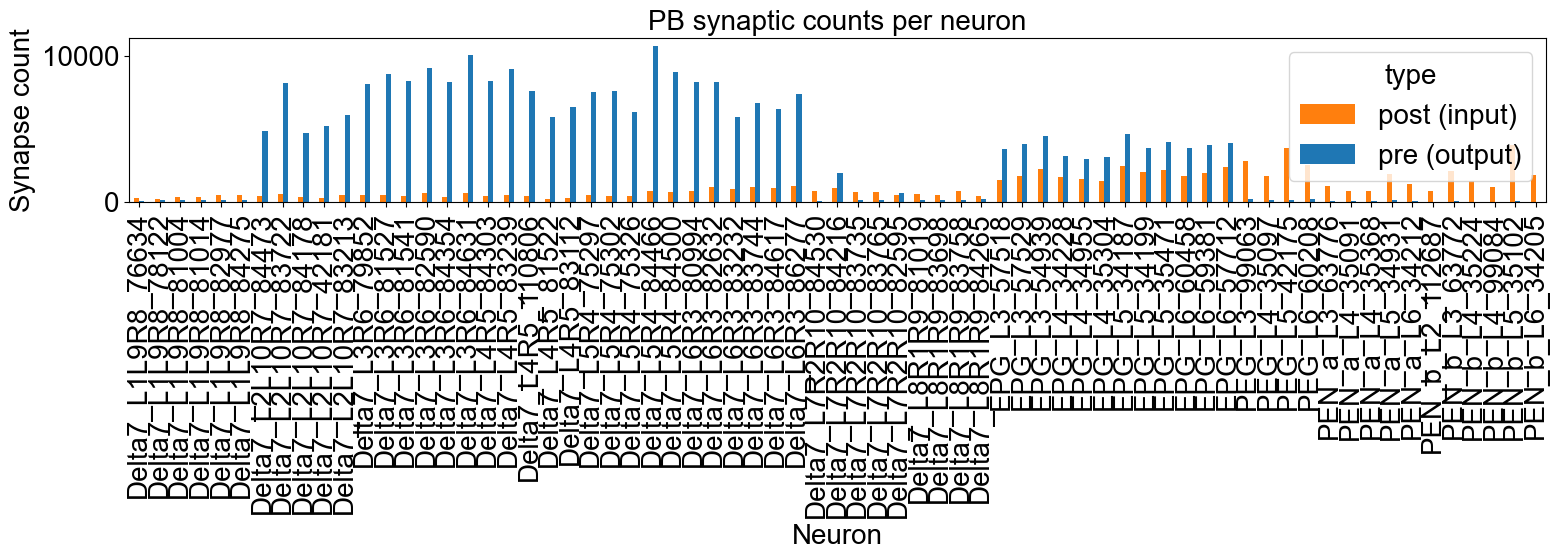

Plot saved: D:\Github\bee-ant-head-direction\analysis\plots\megalopta_synapse_bargraph_EB_20-04-26.pdf


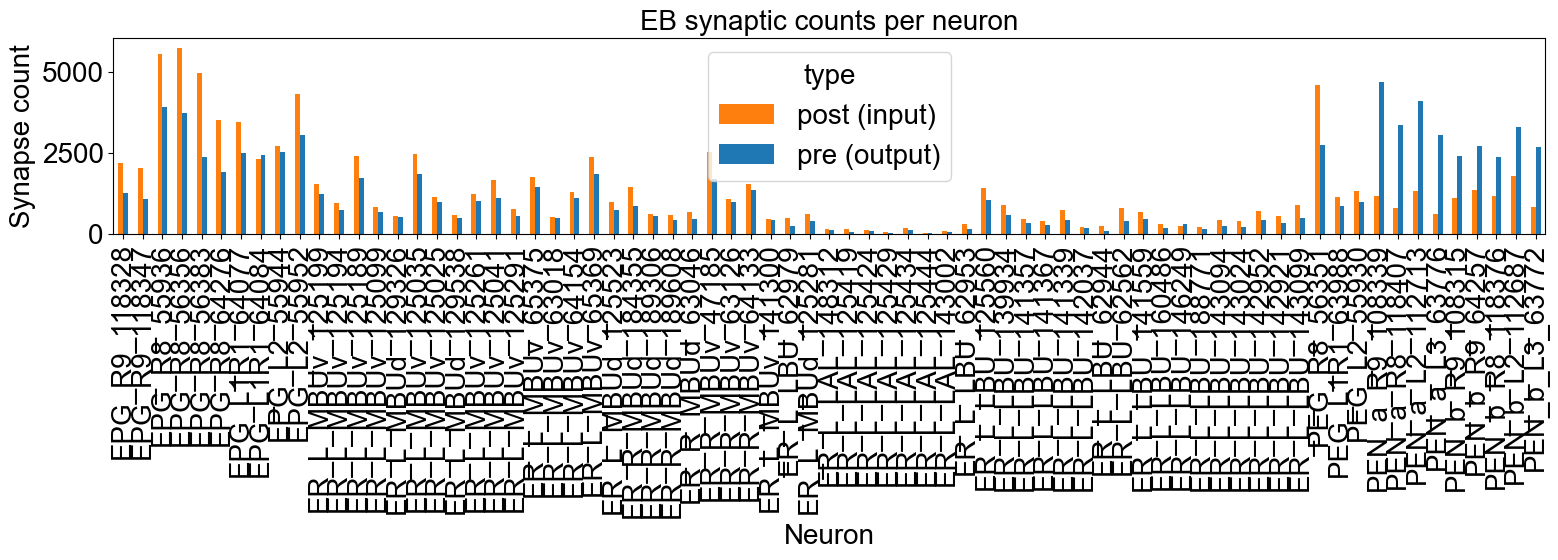

Plot saved: D:\Github\bee-ant-head-direction\analysis\plots\megalopta_synapse_bargraph_NO_20-04-26.pdf


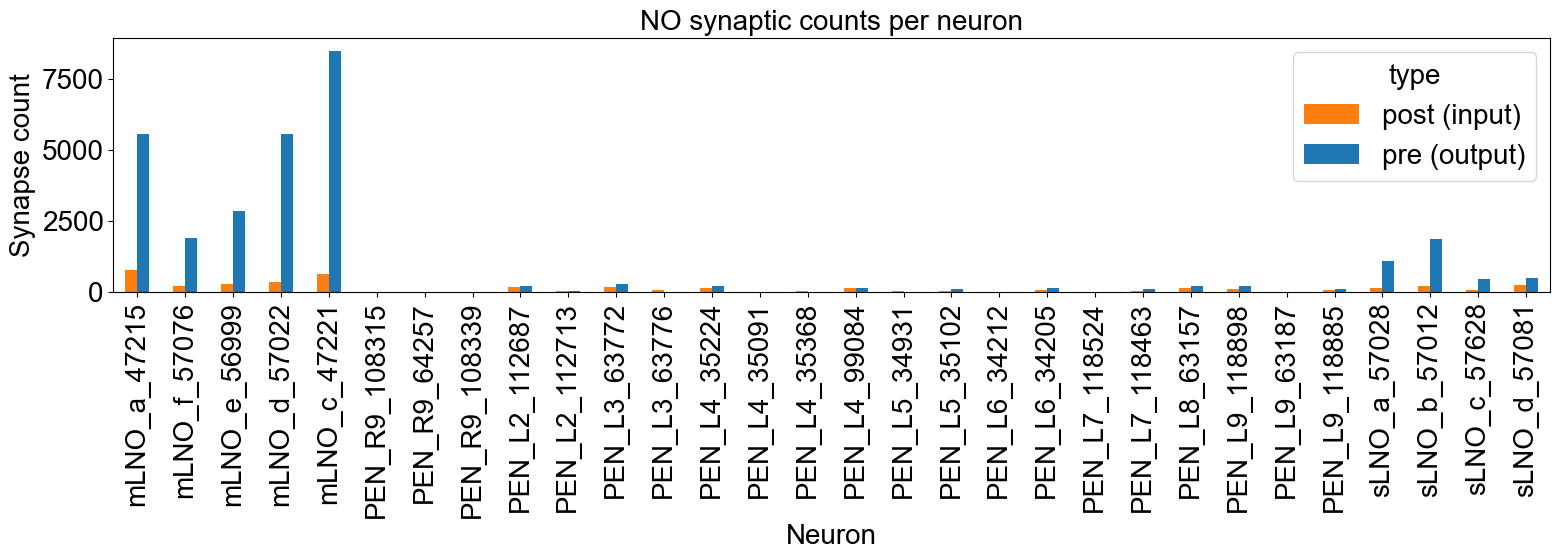

In [18]:
bee_df = bee_syn_df.copy()

bee_pre = (
    bee_df
    .groupby(['pre_name', 'type_pre_col', 'type_pre', 'roi'], as_index=False)
    .size()
    .rename(columns={'size': 'count'})
)
bee_post = (
    bee_df
    .groupby(['post_name', 'type_post_col', 'type_post', 'roi'], as_index=False)
    .size()
    .rename(columns={'size': 'count'})
)

# ROI-specific filtering rules
filters = {
    'PB': r'EPG_R1|EPG_L1|PEG_R1|PEG_L1|EPG_L2|PEG_L2|PEN_a_L2|PEN2_L2|EPG_L7|PEG_L7|PEN_L7|EPG_L8|PEG_L8|PEN_L8|EPG_L9|PEG_L9|PEN_L9|PFN|PFL|PFEx',
    'PB2': r'EPG_R1|EPG_L1|PEG_R1|PEG_L1|EPG_L2|PEG_L2|PEN_a_L2|PEN2_L2|EPG_L7|PEG_L7|PEN_L7|EPG_L8|PEG_L8|PEN_L8|EPG_L9|PEG_L9|PEN_L9|PFN|PFL|PFEx',
    'EB': r'EPG_L3|L4|L5|L6|L7|L8|L9|R6|R5|R4|R3|R2|PFN|PFL|PFE|delta|PEN_R7',
    'NO': r'PFN|ER'
}

# Define color mapping with swapped assignment
color_map = {
    'pre (output)': 'tab:blue',
    'post (input)': 'tab:orange'
}

rois = ['PB', 'EB', 'NO']

for roi in rois:
    # Filter pre
    pre_df = bee_pre[bee_pre['roi'] == roi].copy()
    pre_df = pre_df[~pre_df['pre_name'].str.contains(filters[roi], regex=True)]
    pre_df = pre_df.rename(columns={'pre_name': 'neuron'})
    pre_df['type'] = 'pre (output)'

    # Filter post
    post_df = bee_post[bee_post['roi'] == roi].copy()
    post_df = post_df[~post_df['post_name'].str.contains(filters[roi], regex=True)]
    post_df = post_df.rename(columns={'post_name': 'neuron'})
    post_df['type'] = 'post (input)'

    # Combine and sort
    combined = pd.concat(
        [pre_df[['neuron', 'count', 'type']],
         post_df[['neuron', 'count', 'type']]],
        ignore_index=True
    )
    combined['sort_key'] = combined['neuron'].apply(create_sort_key)

    # Get sorted neuron order
    sorted_neurons = (
        combined[['neuron', 'sort_key']]
        .drop_duplicates()
        .sort_values('sort_key')
        ['neuron']
    )

    # Pivot for plotting
    plot_df = combined.pivot(
        index='neuron',
        columns='type',
        values='count'
    ).fillna(0)

    plot_df = plot_df.loc[sorted_neurons]

    # Plot
    ax = plot_df.plot(
        kind='bar',
        color=[color_map[col] for col in plot_df.columns],
        figsize=(16, 6),
        title=f"{roi} synaptic counts per neuron"
    )
    plt.ylabel("Synapse count")
    plt.xlabel("Neuron")
    plt.xticks(rotation=90)
    plt.tight_layout()

    # Save
    fig_name = f"megalopta_synapse_bargraph_{roi}_{today}.pdf"
    file_path = os.path.join(save_dir, fig_name)
    plt.savefig(file_path, bbox_inches='tight', pad_inches=0, format='pdf')
    print(f"Plot saved: {file_path}")
    plt.show()


In [ ]:
'''compare using heatmap'''

# Ensure consistent structure
cols = ["pre_name", "post_name", "count"]
bo_ = bo[cols].copy()
bc_ = bc[cols].copy()

# Rename counts so they don’t collide
bo_ = bo_.rename(columns={"count": "count_bo"})
bc_ = bc_.rename(columns={"count": "count_bc"})

# Outer merge = union of all edges
df_cmp = bo_.merge(bc_, on=["pre_name", "post_name"], how="outer")

# Fill missing (edges only present in one df)
df_cmp[["count_bo", "count_bc"]] = df_cmp[["count_bo", "count_bc"]].fillna(0)

# Difference
df_cmp["delta"] = df_cmp["count_bc"] - df_cmp["count_bo"]


# Pivot into adjacency matrices
mat_bo = bo.pivot_table(
    index="pre_name", columns="post_name",
    values="count", fill_value=0
)

mat_bc = bc.pivot_table(
    index="pre_name", columns="post_name",
    values="count", fill_value=0
)

# Align (critical!)
mat_bo, mat_bc = mat_bo.align(mat_bc, fill_value=0)

# Difference
mat_delta = mat_bc - mat_bo

plt.figure(figsize=(15, 15))
plt.imshow(mat_delta, aspect='auto')
plt.colorbar(label="Δ synapse count (bc - bo)")
plt.title("Connectivity difference")
plt.xlabel("Post neuron")
plt.ylabel("Pre neuron")

plt.xticks(range(len(mat_delta.columns)), mat_delta.columns, rotation=90)
plt.yticks(range(len(mat_delta.index)), mat_delta.index)

plt.tight_layout()
plt.show()

### figure 1 stacked bar chart

Plot saved: D:\Github\bee-ant-head-direction\analysis\plots\avp_cell_counts_17-04-26.pdf


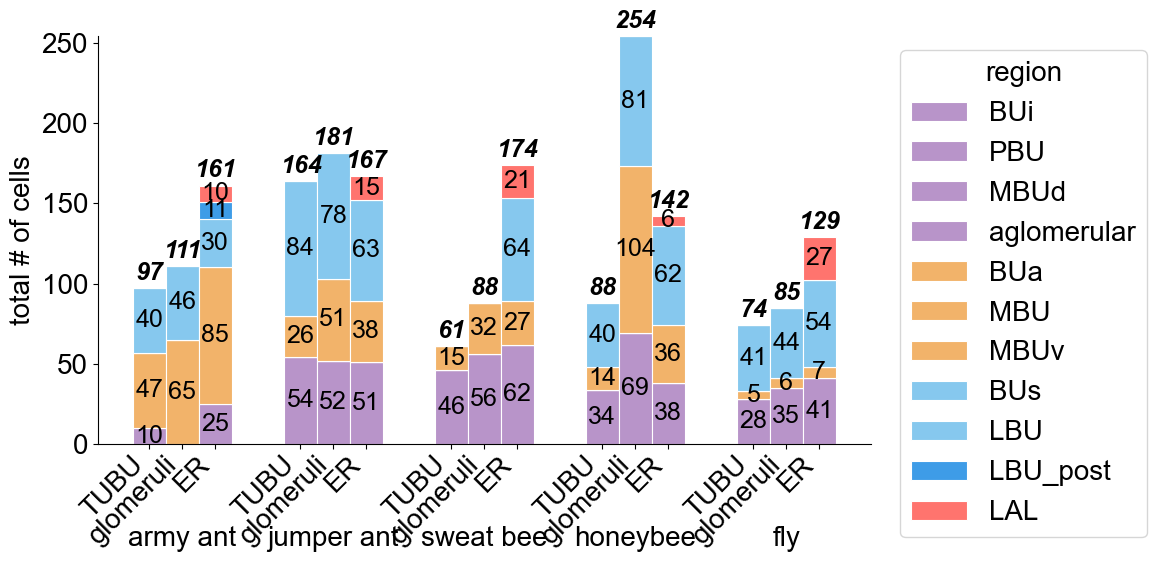

In [5]:
# Load data
avp_counts = pd.read_csv('./cell_count_tables/head_direction_cell_counts - AVP_LBUpost.csv')

# Make counts numeric
avp_counts["right_side_count"] = pd.to_numeric(avp_counts["right_side_count"], errors="coerce")
avp_counts["left_side_count"] = pd.to_numeric(avp_counts["left_side_count"], errors="coerce")

# Use the larger of left vs right for each row
avp_counts["count"] = avp_counts[["left_side_count", "right_side_count"]].max(axis=1)

# Keep needed columns
df = avp_counts[["species", "type", "region", "count"]].copy()

# If there are duplicate species-type-region rows, sum them
df = (
    df.groupby(["species", "type", "region"], as_index=False)["count"]
    .sum()
)

# Order of neuron types within each species
type_order = ["TUBU", "glomeruli", "ER"]

species_order = ["army ant", "jumper ant", "sweat bee", "honeybee", "fly"]

# Pivot to wide format: each row = species/type, columns = region
plot_df = df.pivot_table(
    index=["species", "type"],
    columns="region",
    values="count",
    aggfunc="sum",
    fill_value=0
)

# choose region order manually for consistent stack order
roi_order = [
    "BUi", "PBU", "MBUd", "aglomerular",
    "BUa", "MBU", "MBUv",
    "BUs", "LBU", "LBU_post",
    "LAL",
    "other/uncertain"
]

region_order = [r for r in roi_order if r in plot_df.columns]

# Reorder rows
full_index = pd.MultiIndex.from_product(
    [species_order, type_order],
    names=["species", "type"]
)
plot_df = plot_df.reindex(full_index, fill_value=0)

# Reorder columns
plot_df = plot_df.reindex(columns=region_order, fill_value=0)

# ---- plotting ----
n_species = len(species_order)
n_types = len(type_order)
bar_width = 0.22
group_spacing = 0.35

group_centers = np.arange(n_species) * (n_types * bar_width + group_spacing)

fig, ax = plt.subplots(figsize=(12, 6))

# Optional region colors: edit as needed
region_colors = {
    "MBUd": "#b894c9", # purple
    "PBU": "#b894c9",
    "BUa": "#F2B36A",
    "aglomerular": "#b894c9",
    "MBUv": "#F2B36A", # orange
    "MBU": "#F2B36A",
    "BUi": "#b894c9",
    "LBU": "#86C8EE", # blue
    "LBU_post": "#3E9CE7", # blue
    "BUs": "#86C8EE", 
    "LAL": "#FF746E", # red
    "other/uncertain": "#bdbdbd", # grey
}

# fallback if a region is not in the dict
default_color = "#cccccc"


for i, neuron_type in enumerate(type_order):
    x = group_centers + i * bar_width
    sub = plot_df.xs(neuron_type, level="type")
    
    bottom = np.zeros(len(species_order))
    for region in region_order:
        vals = sub[region].values
        
        ax.bar(
            x,
            vals,
            width=bar_width,
            bottom=bottom,
            label=region if i == 0 else None,
            color=region_colors.get(region, default_color),
            edgecolor="white",
            linewidth=0.8
        )
        
        for xi, yi, bi in zip(x, vals, bottom):
            if yi > 0:
                ax.text(
                    xi,
                    bi + yi / 2,
                    f"{int(yi)}",
                    ha="center",
                    va="center",
                    fontsize=18
                )
        
        bottom += vals

    # total label above each full stacked bar
    for xi, total in zip(x, bottom):
        if total > 0:
            ax.text(
                xi,
                total + 2,
                f"{int(total)}",
                ha="center",
                va="bottom",
                fontsize=18,
                fontweight="bold",
                fontstyle="italic"
            )

# x tick labels should be the type labels, repeated for each species
xtick_positions = []
xtick_labels = []

for j, species in enumerate(species_order):
    for i, neuron_type in enumerate(type_order):
        xtick_positions.append(group_centers[j] + i * bar_width)
        xtick_labels.append(neuron_type)

ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=45, ha="right")

ax.set_ylabel("total # of cells")

# add species labels below the type labels
ymin, ymax = ax.get_ylim()
species_y = -0.20 * ymax

for j, species in enumerate(species_order):
    species_center = group_centers[j] + bar_width
    ax.text(
        species_center,
        species_y,
        species,
        ha="center",
        va="top",
        fontsize=20
    )

ax.tick_params(axis="x", pad=2)
plt.subplots_adjust(bottom=0.22)

ax.legend(title="region", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

file_path = os.path.join(
    save_dir,
    f"avp_cell_counts_{today}.pdf"
)
plt.savefig(file_path, bbox_inches='tight', pad_inches=0, format='pdf')
print(f"Plot saved: {file_path}")

plt.show()

In [5]:
print(avp_counts.columns)

Index(['species', 'region', 'type', 'right_side_count', 'left_side_count',
       'species_total', 'type_total', 'right_side_total', 'left_side_total'],
      dtype='object')


### figure 1: cell count bar plots (old)

Plot saved: D:\Github\bee-ant-head-direction\analysis\plots\er_cell_quantity_02-02-26.pdf


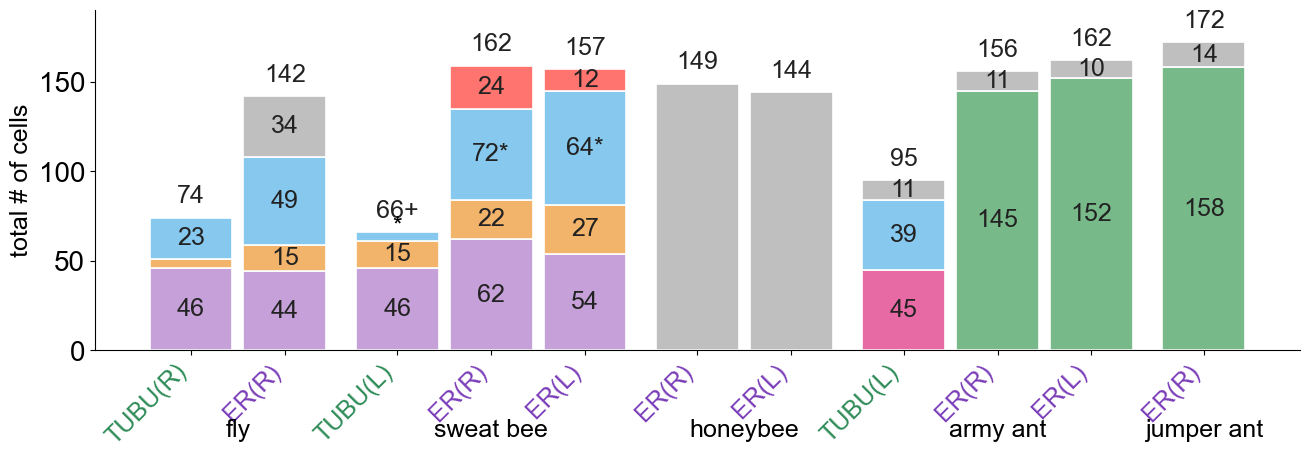

In [51]:
include_legend = False

bars = [
    # fly
    dict(
        label="TUBU(R)", group="fly",
        stack=[("fly_BUa", 46), ("fly_BUi", 5), ("fly_BUs", 23), ("fly_other", 0)],
        total_text="74",
        seg_text_overrides={},
        extra_notes=[]
    ),
    dict(
        label="ER(R)", group="fly",
        stack=[("fly_BUa", 44), ("fly_BUi", 15), ("fly_BUs", 49), ("fly_other", 34)],
        total_text="142",
        seg_text_overrides={},
        extra_notes=[]
    ),

    # sweat bee
    dict(
        label="TUBU(L)", group="sweat bee",
        stack=[("bee_MBUd", 46), ("bee_MBUv", 15), ("bee_LBU", 5), ("bee_LAL", 0)],
        total_text="66+",
        seg_text_overrides={},
        extra_notes=[(0.0, 46 + 15 + 1.5, "*", dict(ha="center", va="bottom", fontsize=18))]
    ),
    dict(
        label="ER(R)", group="sweat bee",
        stack=[("bee_MBUd", 62), ("bee_MBUv", 22), ("bee_LBU", 51), ("bee_LAL", 24)],
        total_text="162",
        seg_text_overrides={"bee_LBU": "72*"},
        extra_notes=[]
    ),
    dict(
        label="ER(L)", group="sweat bee",
        stack=[("bee_MBUd", 54), ("bee_MBUv", 27), ("bee_LBU", 64), ("bee_LAL", 12)],
        total_text="157",
        seg_text_overrides={"bee_LBU": "64*"},
        extra_notes=[]
    ),

    # honeybee (all uncertain/other)
    dict(
        label="ER(R)", group="honeybee",
        stack=[("bee_other", 149)],
        total_text="149",
        seg_text_overrides={},
        extra_notes=[]
    ),
    dict(
        label="ER(L)", group="honeybee",
        stack=[("bee_other", 144)],
        total_text="144",
        seg_text_overrides={},
        extra_notes=[]
    ),

    # army ant
    dict(
        label="TUBU(L)", group="army ant",
        stack=[("ant_MBU", 45), ("ant_LBU", 39), ("ant_other", 11)],
        total_text="95",
        seg_text_overrides={},
        extra_notes=[]
    ),
    dict(
        label="ER(R)", group="army ant",
        stack=[("ant_BU", 145), ("ant_other", 11)],
        total_text="156",
        seg_text_overrides={},
        extra_notes=[]
    ),
    dict(
        label="ER(L)", group="army ant",
        stack=[("ant_BU", 152), ("ant_other", 10)],
        total_text="162",
        seg_text_overrides={},
        extra_notes=[]
    ),

    # jumper ant
    dict(
        label="ER(R)", group="jumper ant",
        stack=[("ant_BU", 158), ("ant_other", 14)],
        total_text="172",
        seg_text_overrides={},
        extra_notes=[]
    ),
]

# -----------------------------
# Colors (matched to figure)
# -----------------------------
COL = {
    # fly
    "fly_BUa":   "#c6a0d8",  # light purple
    "fly_BUi":   "#f2b36a",  # orange
    "fly_BUs":   "#86c8ee",  # light blue
    "fly_other": "#bfbfbf",  # grey

    # bee
    "bee_MBUd":  "#c6a0d8",  # same purple tone
    "bee_MBUv":  "#f2b36a",
    "bee_LBU":   "#86c8ee",
    "bee_LAL": "#FF746E",
    "bee_other": "#bfbfbf",

    # ants
    "ant_BU":    "#78b989",  # green
    "ant_MBU":   "#e86aa5",  # pink/magenta
    "ant_LBU":   "#86c8ee",
    "ant_other": "#bfbfbf",
}

# Tick-label color cues in the figure (TUBU green, ER purple)
TICK_COL = {
    "TUBU": "#2e8b57",
    "ER":   "#7a3db8",
}

# -----------------------------
# Layout: x positions with gaps between groups
# -----------------------------
group_order = ["fly", "sweat bee", "honeybee", "army ant", "jumper ant"]

x_positions = []
group_centers = {}
x = 0.0
bar_w = 0.9
within_gap = 0.02
between_group_gap = 0.2

# compute x positions
for g in group_order:
    idxs = [i for i, b in enumerate(bars) if b["group"] == g]
    if not idxs:
        continue
    start_x = x
    for _ in idxs:
        x_positions.append(x)
        x += 1.0 + within_gap
    end_x = x - (1.0 + within_gap)
    group_centers[g] = (start_x + end_x) / 2.0
    x += between_group_gap

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(13.5, 5))

def add_in_segment_text(ax, x0, bottom, height, text, color="#222222"):
    if height <= 0:
        return
    ax.text(
        x0, bottom + height / 2.0, text,
        ha="center", va="center", fontsize=18, color=color
    )

# draw bars
for i, b in enumerate(bars):
    x0 = x_positions[i]
    bottom = 0.0

    # stacked rectangles
    for key, val in b["stack"]:
        if val <= 0:
            continue
        ax.bar(
            x0, val, width=bar_w, bottom=bottom,
            color=COL[key], edgecolor="white", linewidth=1.2
        )

        # in-segment labels (match figure: show most segments; skip single grey-only bars)
        show = True
        if len(b["stack"]) == 1 and "other" in key:
            show = False
        if show and val >= 8:  # avoid tiny slivers clutter
            txt = b.get("seg_text_overrides", {}).get(key, str(val))
            add_in_segment_text(ax, x0, bottom, val, txt)

        bottom += val

    total = sum(v for _, v in b["stack"])
    # total text above
    ax.text(x0, total + 5.5, b["total_text"], ha="center", va="bottom", fontsize=18, color="#222222")

    # extra annotations like "*"
    for (dx, y, t, kw) in b.get("extra_notes", []):
        ax.text(x0 + dx, y, t, **kw)

# axes styling
ax.set_ylabel("total # of cells", fontsize=18)
ax.set_ylim(0, 190)
ax.set_yticks([0, 50, 100, 150])

# x ticks
xticks = x_positions
xlabels = [b["label"] for b in bars]
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, rotation=45, ha="right", fontsize=18)

# color tick labels by prefix (TUBU vs ER)
for tick, lbl in zip(ax.get_xticklabels(), xlabels):
    if lbl.startswith("TUBU"):
        tick.set_color(TICK_COL["TUBU"])
    elif lbl.startswith("ER"):
        tick.set_color(TICK_COL["ER"])

# group labels under the x-axis (like the figure: fly / sweat bee / honeybee / army ant / jumper ant)
y_text = -0.20  # in axes coords
for g in group_order:
    if g in group_centers:
        ax.text(
            group_centers[g], y_text, g,
            transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=18
        )

# clean spines similar to the figure
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# -----------------------------
# Legend (3 separate mini-legends like the panel)
# -----------------------------
from matplotlib.patches import Patch
if include_legend == True:
    fly_legend = [
        Patch(facecolor=COL["fly_BUa"], edgecolor="none", label="BUa"),
        Patch(facecolor=COL["fly_BUi"], edgecolor="none", label="BUi"),
        Patch(facecolor=COL["fly_BUs"], edgecolor="none", label="BUs"),
        Patch(facecolor=COL["fly_other"], edgecolor="none", label="other"),
    ]
    bee_legend = [
        Patch(facecolor=COL["bee_MBUd"], edgecolor="none", label="MBUd"),
        Patch(facecolor=COL["bee_MBUv"], edgecolor="none", label="MBUv"),
        Patch(facecolor=COL["bee_LBU"], edgecolor="none", label="LBU"),
        Patch(facecolor=COL["bee_LAL"], edgecolor="none", label="LAL"),
        Patch(facecolor=COL["bee_other"], edgecolor="none", label="other/\nuncertain"),
    ]
    ant_legend = [
        Patch(facecolor=COL["ant_BU"], edgecolor="none", label="BU (ant)"),
        Patch(facecolor=COL["ant_MBU"], edgecolor="none", label="MBU (ant)"),
        Patch(facecolor=COL["ant_LBU"], edgecolor="none", label="LBU (ant)"),
        Patch(facecolor=COL["ant_other"], edgecolor="none", label="other/\nuncertain"),
    ]
    
    leg1 = ax.legend(handles=fly_legend, title="fly:", frameon=False,
                     loc="upper left", bbox_to_anchor=(-0.27, 0.98),
                     borderaxespad=0.0, handlelength=0.9, handletextpad=0.4)
    ax.add_artist(leg1)
    
    leg2 = ax.legend(handles=bee_legend, title="bee:", frameon=False,
                     loc="upper left", bbox_to_anchor=(-0.16, 0.98),
                     borderaxespad=0.0, handlelength=0.9, handletextpad=0.4)
    ax.add_artist(leg2)
    
    leg3 = ax.legend(handles=ant_legend, title="ant:", frameon=False,
                     loc="upper left", bbox_to_anchor=(-0.03, 0.98),
                     borderaxespad=0.0, handlelength=0.9, handletextpad=0.4)

# panel letter "g"
# ax.text(-0.33, 1.03, "g", transform=ax.transAxes, fontsize=22, fontweight="bold", va="top")

plt.tight_layout()

# Save
fig_name = f"er_cell_quantity_{today}.pdf"
file_path = os.path.join(save_dir, fig_name)
plt.savefig(file_path, bbox_inches='tight', pad_inches=0, format='pdf')
print(f"Plot saved: {file_path}")
plt.show()

Plot saved: D:\Github\bee-ant-head-direction\analysis\plots\pen_cell_quantity_02-02-26.pdf


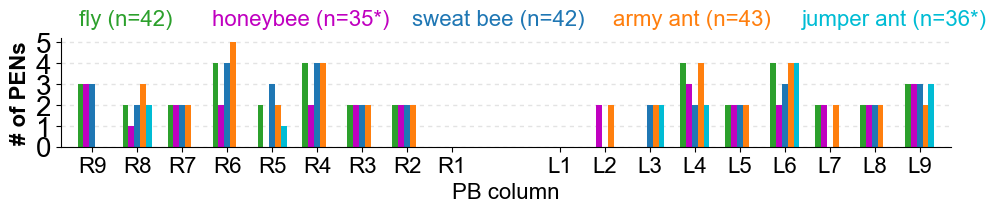

In [45]:
#!/usr/bin/env python3
"""
Recreate the PB-column grouped bar plot (fly / honeybee / sweat bee / army ant / jumper ant).

Dependencies:
  pip install matplotlib numpy pandas

How to use:
  - Edit COUNTS below (or load from a CSV into a DataFrame; template included).
  - Run the script. It will render a plot closely matching the provided figure.
"""
# ------------------------------------------------------------
# 1) Data
# ------------------------------------------------------------
# PB columns shown in the figure (include R1 and L1 even if 0, for spacing/labels)
PB_COLS = ["R9","R8","R7","R6","R5","R4","R3","R2","R1","L1","L2","L3","L4","L5","L6","L7","L8","L9"]

# Species order (matches legend/title order in your image)
SPECIES = ["fly", "honeybee", "sweat bee", "army ant", "jumper ant"]

# Example counts (REPLACE these with your real numbers).
# Structure: {species: {pb_col: count, ...}, ...}
# Tip: keep zeros for columns with no bars so spacing matches the figure.
COUNTS = {
    "fly":       {"R9":3,"R8":2,"R7":2,"R6":4,"R5":2,"R4":4,"R3":2,"R2":2,"R1":0,"L1":0,"L2":0,"L3":0,"L4":4,"L5":2,"L6":4,"L7":2,"L8":2,"L9":3},
    "honeybee":  {"R9":3,"R8":1,"R7":2,"R6":2,"R5":0,"R4":2,"R3":2,"R2":2,"R1":0,"L1":0,"L2":2,"L3":0,"L4":3,"L5":2,"L6":2,"L7":2,"L8":2,"L9":3},
    "sweat bee": {"R9":3,"R8":2,"R7":2,"R6":4,"R5":3,"R4":4,"R3":2,"R2":2,"R1":0,"L1":0,"L2":0,"L3":2,"L4":2,"L5":2,"L6":3,"L7":0,"L8":2,"L9":3},
    "army ant":  {"R9":0,"R8":3,"R7":2,"R6":5,"R5":2,"R4":4,"R3":2,"R2":2,"R1":0,"L1":0,"L2":2,"L3":2,"L4":4,"L5":2,"L6":4,"L7":2,"L8":2,"L9":2},
    "jumper ant":{"R9":0,"R8":2,"R7":0,"R6":0,"R5":1,"R4":0,"R3":0,"R2":0,"R1":0,"L1":0,"L2":0,"L3":2,"L4":2,"L5":0,"L6":4,"L7":0,"L8":0,"L9":3},
}

# If you'd rather load from CSV, use this format:
# pb_col,species,count
# R9,fly,3
# ...
# df = pd.read_csv("pfn_counts.csv")

# Build a DataFrame from COUNTS
rows = []
for sp in SPECIES:
    for col in PB_COLS:
        rows.append({"pb_col": col, "species": sp, "count": COUNTS[sp].get(col, 0)})
df = pd.DataFrame(rows)

# ------------------------------------------------------------

# Species colors 
COLORS = {
    "fly": "#2ca02c",        # green
    "honeybee": "#c000c0",   # magenta/purple
    "sweat bee": "#1f77b4",  # blue
    "army ant": "#ff7f0e",   # orange
    "jumper ant": "#00bcd4", # cyan-ish
}

# Title text exactly like your figure
TITLE_PARTS = [
    ("fly (n=42)", COLORS["fly"]),
    ("honeybee (n=35*)", COLORS["honeybee"]),
    ("sweat bee (n=42)", COLORS["sweat bee"]),
    ("army ant (n=43)", COLORS["army ant"]),
    ("jumper ant (n=36*)", COLORS["jumper ant"]),
]

# ------------------------------------------------------------
# 3) Compute x positions (add a visual gap between R-side and L-side)
# ------------------------------------------------------------
x = np.arange(len(PB_COLS), dtype=float)

# Create a bigger gap between R1 and L1 like the figure
# (R side indices 0..8, L side indices 9..17)
gap = 1.4
x[9:] += gap

# Bar geometry: thin grouped bars
group_n = len(SPECIES)
bar_w = 0.13
# Center the group on each tick
offsets = (np.arange(group_n) - (group_n - 1) / 2) * bar_w

# ------------------------------------------------------------
# 4) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10.5, 2.6))

for i, sp in enumerate(SPECIES):
    y = df[df["species"] == sp].set_index("pb_col").loc[PB_COLS, "count"].to_numpy()
    ax.bar(x + offsets[i], y, width=bar_w, color=COLORS[sp], linewidth=0)

# Axes formatting
ax.set_xlim(x.min() - 0.7, x.max() + 0.7)
ax.set_ylim(0, 5.2)
ax.set_yticks(np.arange(0, 6, 1))
ax.set_ylabel("# of PENs", fontsize=16, fontweight="bold")
ax.set_xlabel("PB column", fontsize=16)

ax.set_xticks(x)
ax.set_xticklabels(PB_COLS, fontsize=16)

# Horizontal dashed gridlines like the figure
ax.yaxis.grid(True, linestyle=(0, (3, 3)), linewidth=1, alpha=0.35)
ax.set_axisbelow(True)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# 5) Multi-colored title line (manually placed text)
# ------------------------------------------------------------

x0 = 0.02
y0 = 1.08
char_scale = 0.0125  # tweak to tighten/loosen spacing between title segments
for text, color in TITLE_PARTS:
    ax.text(x0, y0, text, transform=ax.transAxes, ha="left", va="bottom",
            fontsize=16, color=color)
    x0 += char_scale * (len(text) + 2)

plt.tight_layout()

# Save
fig_name = f"pen_cell_quantity_{today}.pdf"
file_path = os.path.join(save_dir, fig_name)
plt.savefig(file_path, bbox_inches='tight', pad_inches=0, format='pdf')
print(f"Plot saved: {file_path}")
plt.show()


Plot saved: D:\Github\bee-ant-head-direction\analysis\plots\epg_cell_quantity_02-02-26.pdf


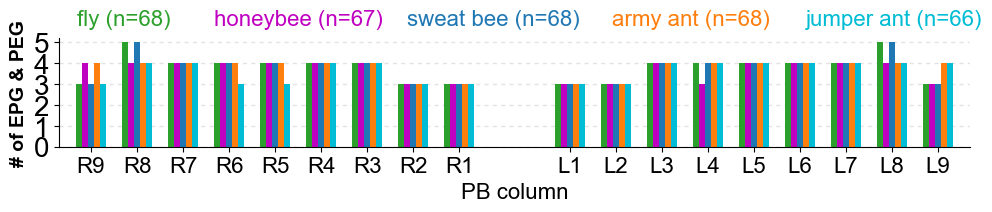

In [50]:
# ------------------------------------------------------------
# 1) Data
# ------------------------------------------------------------
# PB columns shown in the figure (include R1 and L1 even if 0, for spacing/labels)
PB_COLS = ["R9","R8","R7","R6","R5","R4","R3","R2","R1","L1","L2","L3","L4","L5","L6","L7","L8","L9"]

# Species order (matches legend/title order in your image)
SPECIES = ["fly", "honeybee", "sweat bee", "army ant", "jumper ant"]

# keep zeros for columns with no bars so spacing matches the figure.
# keep zeros for columns with no bars so spacing matches the figure.
COUNTS = {
    "fly": {
        "R9":3,"R8":5,"R7":4,"R6":4,"R5":4,"R4":4,"R3":4,"R2":3,"R1":3,
        "L1":3,"L2":3,"L3":4,"L4":4,"L5":4,"L6":4,"L7":4,"L8":5,"L9":3
    },
    "honeybee": {
        "R9":4,"R8":4,"R7":4,"R6":4,"R5":4,"R4":4,"R3":4,"R2":3,"R1":3,
        "L1":3,"L2":3,"L3":4,"L4":3,"L5":4,"L6":4,"L7":4,"L8":4,"L9":3
    },
    "sweat bee": {
        "R9":3,"R8":5,"R7":4,"R6":4,"R5":4,"R4":4,"R3":4,"R2":3,"R1":3,
        "L1":3,"L2":3,"L3":4,"L4":4,"L5":4,"L6":4,"L7":4,"L8":5,"L9":3
    },
    "army ant": {
        "R9":4,"R8":4,"R7":4,"R6":4,"R5":4,"R4":4,"R3":4,"R2":3,"R1":3,
        "L1":3,"L2":3,"L3":4,"L4":4,"L5":4,"L6":4,"L7":4,"L8":4,"L9":4
    },
    "jumper ant": {
        "R9":3,"R8":4,"R7":4,"R6":3,"R5":3,"R4":4,"R3":4,"R2":3,"R1":3,
        "L1":3,"L2":3,"L3":4,"L4":4,"L5":4,"L6":4,"L7":4,"L8":4,"L9":4
    },
}


# Build a DataFrame from COUNTS
rows = []
for sp in SPECIES:
    for col in PB_COLS:
        rows.append({"pb_col": col, "species": sp, "count": COUNTS[sp].get(col, 0)})
df = pd.DataFrame(rows)

# ------------------------------------------------------------

# Species colors 
COLORS = {
    "fly": "#2ca02c",        # green
    "honeybee": "#c000c0",   # magenta/purple
    "sweat bee": "#1f77b4",  # blue
    "army ant": "#ff7f0e",   # orange
    "jumper ant": "#00bcd4", # cyan-ish
}

# Title text exactly like your figure
TITLE_PARTS = [
    ("fly (n=68)", COLORS["fly"]),
    ("honeybee (n=67)", COLORS["honeybee"]),
    ("sweat bee (n=68)", COLORS["sweat bee"]),
    ("army ant (n=68)", COLORS["army ant"]),
    ("jumper ant (n=66)", COLORS["jumper ant"]),
]

# ------------------------------------------------------------
# 3) Compute x positions (add a visual gap between R-side and L-side)
# ------------------------------------------------------------
x = np.arange(len(PB_COLS), dtype=float)

# Create a bigger gap between R1 and L1 like the figure
# (R side indices 0..8, L side indices 9..17)
gap = 1.4
x[9:] += gap

# Bar geometry: thin grouped bars
group_n = len(SPECIES)
bar_w = 0.13
# Center the group on each tick
offsets = (np.arange(group_n) - (group_n - 1) / 2) * bar_w

# ------------------------------------------------------------
# 4) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10.5, 2.6))

for i, sp in enumerate(SPECIES):
    y = df[df["species"] == sp].set_index("pb_col").loc[PB_COLS, "count"].to_numpy()
    ax.bar(x + offsets[i], y, width=bar_w, color=COLORS[sp], linewidth=0)

# Axes formatting
ax.set_xlim(x.min() - 0.7, x.max() + 0.7)
ax.set_ylim(0, 5.2)
ax.set_yticks(np.arange(0, 6, 1))
ax.set_ylabel("# of EPG & PEG", fontsize=14, fontweight="bold") 

ax.set_xlabel("PB column", fontsize=16)

ax.set_xticks(x)
ax.set_xticklabels(PB_COLS, fontsize=16)

# Horizontal dashed gridlines like the figure
ax.yaxis.grid(True, linestyle=(0, (3, 3)), linewidth=1, alpha=0.35)
ax.set_axisbelow(True)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# 5) Multi-colored title line (manually placed text)
# ------------------------------------------------------------

x0 = 0.02
y0 = 1.08
char_scale = 0.0125  # tweak to tighten/loosen spacing between title segments
for text, color in TITLE_PARTS:
    ax.text(x0, y0, text, transform=ax.transAxes, ha="left", va="bottom",
            fontsize=16, color=color)
    x0 += char_scale * (len(text) + 2)

plt.tight_layout()

# Save
fig_name = f"epg_cell_quantity_{today}.pdf"
file_path = os.path.join(save_dir, fig_name)
plt.savefig(file_path, bbox_inches='tight', pad_inches=0, format='pdf')
print(f"Plot saved: {file_path}")
plt.show()


Plot saved: D:\Github\bee-ant-head-direction\analysis\plots\d7_cell_quantity_02-02-26.pdf


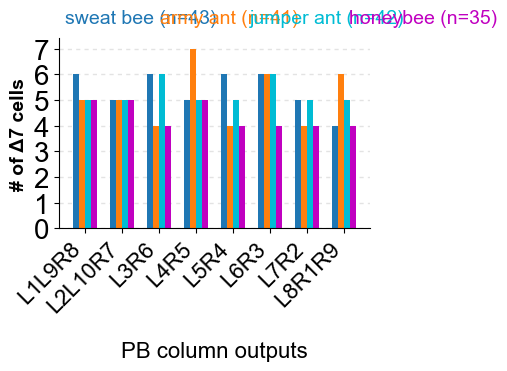

In [49]:
# Δ7 bar plot


X = ["L1L9R8", "L2L10R7", "L3R6", "L4R5", "L5R4", "L6R3", "L7R2", "L8R1R9"]

COUNTS = {
    "sweat bee":  [6, 5, 6, 5, 6, 6, 5, 4],
    "army ant":   [5, 5, 4, 7, 4, 6, 4, 6],
    "jumper ant":[5, 5, 6, 5, 5, 6, 5, 5],
    "honeybee":  [5, 5, 4, 5, 4, 4, 4, 4],
}

# -----------------------------
# Styling
# -----------------------------
# Species colors (approximate to your figure)
COLORS = {
    "honeybee": "#c000c0",   # magenta/purple
    "sweat bee": "#1f77b4",  # blue
    "army ant": "#ff7f0e",   # orange
    "jumper ant": "#00bcd4", # cyan-ish
}

TITLE_PARTS = [
    ("sweat bee (n=43)", COLORS["sweat bee"]),
    ("   ", "black"),
    ("army ant (n=41)", COLORS["army ant"]),
    ("   ", "black"),
    ("jumper ant (n=42)", COLORS["jumper ant"]),
    ("   ", "black"),
    ("honeybee (n=35)", COLORS["honeybee"]),
]

SPECIES = list(COUNTS.keys())

# -----------------------------
# Geometry
# -----------------------------
x = np.arange(len(X), dtype=float)
group_n = len(SPECIES)

bar_w = 0.16
offsets = (np.arange(group_n) - (group_n - 1) / 2) * bar_w

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(5.4, 4.2))

for i, sp in enumerate(SPECIES):
    ax.bar(
        x + offsets[i],
        COUNTS[sp],
        width=bar_w,
        color=COLORS[sp],
        linewidth=0
    )

# Axes
ax.set_ylim(0, 7.4)
ax.set_yticks(np.arange(0, 8, 1))
ax.set_ylabel("# of Δ7 cells", fontsize=14, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(X, rotation=45, ha="right", fontsize=16)

ax.set_xlabel("PB column outputs", fontsize=16, labelpad=18)

# Gridlines
ax.yaxis.grid(True, linestyle=(0, (3, 3)), linewidth=1, alpha=0.35)
ax.set_axisbelow(True)

# Spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# -----------------------------
# Multicolour title
# -----------------------------
x0 = 0.02
y0 = 1.06
char_scale = 0.016

for text, color in TITLE_PARTS:
    ax.text(
        x0, y0, text,
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=14,
        color=color
    )
    x0 += char_scale * len(text)

plt.tight_layout()

# Save
fig_name = f"d7_cell_quantity_{today}.pdf"
file_path = os.path.join(save_dir, fig_name)
plt.savefig(file_path, bbox_inches='tight', pad_inches=0, format='pdf')
print(f"Plot saved: {file_path}")
plt.show()


### sweat bee and army ant volume comparisons (not included in preprint analysis)

In [4]:
eciton_cx_vol = 816103.300 + 255372.650 + 22264.351 + 21802.032 + 196528.360
megalopta_cx_vol = 5225480.600 + 1344898.400 + 344946.670 + 358750.160 + 874669.500
print(megalopta_cx_vol / eciton_cx_vol)

6.229590933889993


In [9]:
# quick fix
import sys
import pandas as pd
import numpy as np
import navis
import pymaid
import random
import re
import ast
import json


import skeletor as sk
import cloudvolume as cv
import fafbseg
import caveclient
import k3d

D:\flywire_backup\cave\cave\lib\site-packages\blessed\terminal.py:183: UserWarning: Failed to setupterm(kind='xterm-color'): Could not find terminal xterm-color
  warnings.warn(msg)


In [10]:
path = 'D:/flywire_backup/cave/cat_client.json' # replace with your path

with open(path, 'r') as f:
    conn_file = json.load(f)
api_token = conn_file['api_token']
http_user = conn_file['http_user']
http_password = conn_file['http_password']
server = conn_file['server']

eciton_client = pymaid.CatmaidInstance(server = server, 
                                api_token = api_token,
                                caching = True,
                                project_id = 7,
                                http_user = http_user,
                                http_password = http_password 
                                )

megalopt_client = pymaid.CatmaidInstance(server = server, 
                                api_token = api_token,
                                caching = True,
                                project_id = 8,
                                http_user = http_user,
                                http_password = http_password 
                                )

INFO  : Global CATMAID instance set. Caching is ON. (pymaid)
INFO  : Global CATMAID instance set. Caching is ON. (pymaid)


In [7]:
# import synapse tables
beesyn = pd.read_csv('../syntables/table_csv_files/synapses_250825/NO_all_syns_feb8_with-roots_with-sk_25-08-25.csv')
antsyn = pd.read_csv('../syntables/table_csv_files/eciton_cx_syntable_27-16-25.csv')

C:\Users\Marcel\AppData\Local\Temp\ipykernel_17612\55201597.py:2: DtypeWarning: Columns (2,9,11) have mixed types. Specify dtype option on import or set low_memory=False.
  antsyn = pd.read_csv('../syntables/table_csv_files/eciton_cx_syntable_27-12-25.csv')


In [11]:
for df in (beesyn, antsyn):
    df['pre_skid'] = pd.to_numeric(df['pre_skid'], errors='coerce')
    df['post_skid'] = pd.to_numeric(df['post_skid'], errors='coerce')


# LNO skids
eciton_LNO = [29744, 29755]
megalopta_LNO = [57016, 57081]

bee_filt = beesyn[
    beesyn['pre_skid'].isin(megalopta_LNO).fillna(False) |
    beesyn['post_skid'].isin(megalopta_LNO).fillna(False)
]

ant_filt = antsyn[
    antsyn['pre_skid'].isin(eciton_LNO).fillna(False) |
    antsyn['post_skid'].isin(eciton_LNO).fillna(False)
]


### Fig. 2 supp. 3 bee and fly plotted side by side

***NOTE: neither datasets contain noduli synapses, so PENs are an undercount***

In [19]:
fly_syn_df[fly_syn_df['type_pre'].str.contains(r'PEG') & fly_syn_df['type_post'].str.contains(r'EPG')]

,Unnamed: 0.1,Unnamed: 0,bodyId_pre,bodyId_post,roi_pre,roi_post,x_pre,y_pre,z_pre,x_post,...,confidence_pre,confidence_post,type_pre,instance_pre,type_post,instance_post,type_pre_col,type_post_col,pre_name,post_name
1612,10468,10468,881898734,541870397,PB,PB,32331,15464,14185,32334,...,0.723,0.948000,PEG,PEG(PB07)_L6,EPG,EPG(PB08)_L6,PEG_L6,EPG_L6,PEG_L6_881898734,EPG_L6_541870397
4836,13781,13781,1128088594,572870540,EB,EB,25288,25016,22908,25266,...,0.910,0.801000,PEG,PEG(PB07)_L1,EPG,EPG(PB08)_L1,PEG_L1,EPG_L1,PEG_L1_1128088594,EPG_L1_572870540
4837,13782,13782,1128088594,572870540,EB,EB,25857,25466,22939,25866,...,0.946,0.650820,PEG,PEG(PB07)_L1,EPG,EPG(PB08)_L1,PEG_L1,EPG_L1,PEG_L1_1128088594,EPG_L1_572870540
4838,13783,13783,1128088594,572870540,EB,EB,25746,24075,23035,25740,...,0.979,0.905867,PEG,PEG(PB07)_L1,EPG,EPG(PB08)_L1,PEG_L1,EPG_L1,PEG_L1_1128088594,EPG_L1_572870540
4839,13784,13784,1128088594,572870540,EB,EB,26006,25049,23188,25995,...,0.982,0.814167,PEG,PEG(PB07)_L1,EPG,EPG(PB08)_L1,PEG_L1,EPG_L1,PEG_L1_1128088594,EPG_L1_572870540
4856,13801,13801,1125969082,572870540,EB,EB,25391,23973,22378,25376,...,0.833,0.907224,PEG,PEG(PB07)_R9,EPG,EPG(PB08)_L1,PEG_R9,EPG_L1,PEG_R9_1125969082,EPG_L1_572870540
4857,13802,13802,1125969082,572870540,EB,EB,25459,23970,22446,25453,...,0.945,0.342408,PEG,PEG(PB07)_R9,EPG,EPG(PB08)_L1,PEG_R9,EPG_L1,PEG_R9_1125969082,EPG_L1_572870540
6359,23176,23176,5813059834,697001770,EB,EB,23353,25225,22499,23354,...,0.910,0.725000,PEG,PEG(PB07)_R8,EPG,EPG(PB08)_L2,PEG_R8,EPG_L2,PEG_R8_5813059834,EPG_L2_697001770
6360,23177,23177,5813059834,697001770,EB,EB,23390,24702,22431,23401,...,0.646,0.878000,PEG,PEG(PB07)_R8,EPG,EPG(PB08)_L2,PEG_R8,EPG_L2,PEG_R8_5813059834,EPG_L2_697001770
7768,24590,24590,1190171884,697001770,EB,EB,23211,24601,21570,23233,...,0.976,0.481646,PEG,PEG(PB07)_L2,EPG,EPG(PB08)_L2,PEG_L2,EPG_L2,PEG_L2_1190171884,EPG_L2_697001770


In [14]:
# import data (takes a min)
fly_syn_df = pd.read_csv('../syntables/table_csv_files/fly_hemibrain_beeROI_syntable.csv') # use filtered to bee ROI
bee_syn_df = pd.read_csv('../syntables/table_csv_files/megalopta_cx_syntable_19-04-26.csv')

# a bit slow, but works
# bee_syn_df = bee_syn_df.replace(to_replace=r'\bdelta7', value='Delta7', regex=True)
fly_syn_df = fly_syn_df.replace(to_replace=r'\bEPGt_R9', value='EPG_R9(EPGt)', regex=True)

# bee_syn_df = bee_syn_df[~bee_syn_df['roi'].str.contains(r'NO', na=False)] # remove noduli synapses
# bee_syn_df = bee_syn_df[~bee_syn_df['roi'].str.contains(r'NO', na=False)] # remove noduli synapses

C:\Users\Marcel\AppData\Local\Temp\ipykernel_22968\146796282.py:3: DtypeWarning: Columns (2,3,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  bee_syn_df = pd.read_csv('../syntables/table_csv_files/megalopta_cx_syntable_19-04-26.csv')


Plot saved: D:\Github\bee-ant-head-direction\analysis\plots\bee_fly_synapse_bargraphs_allROIs_21-04-26.pdf


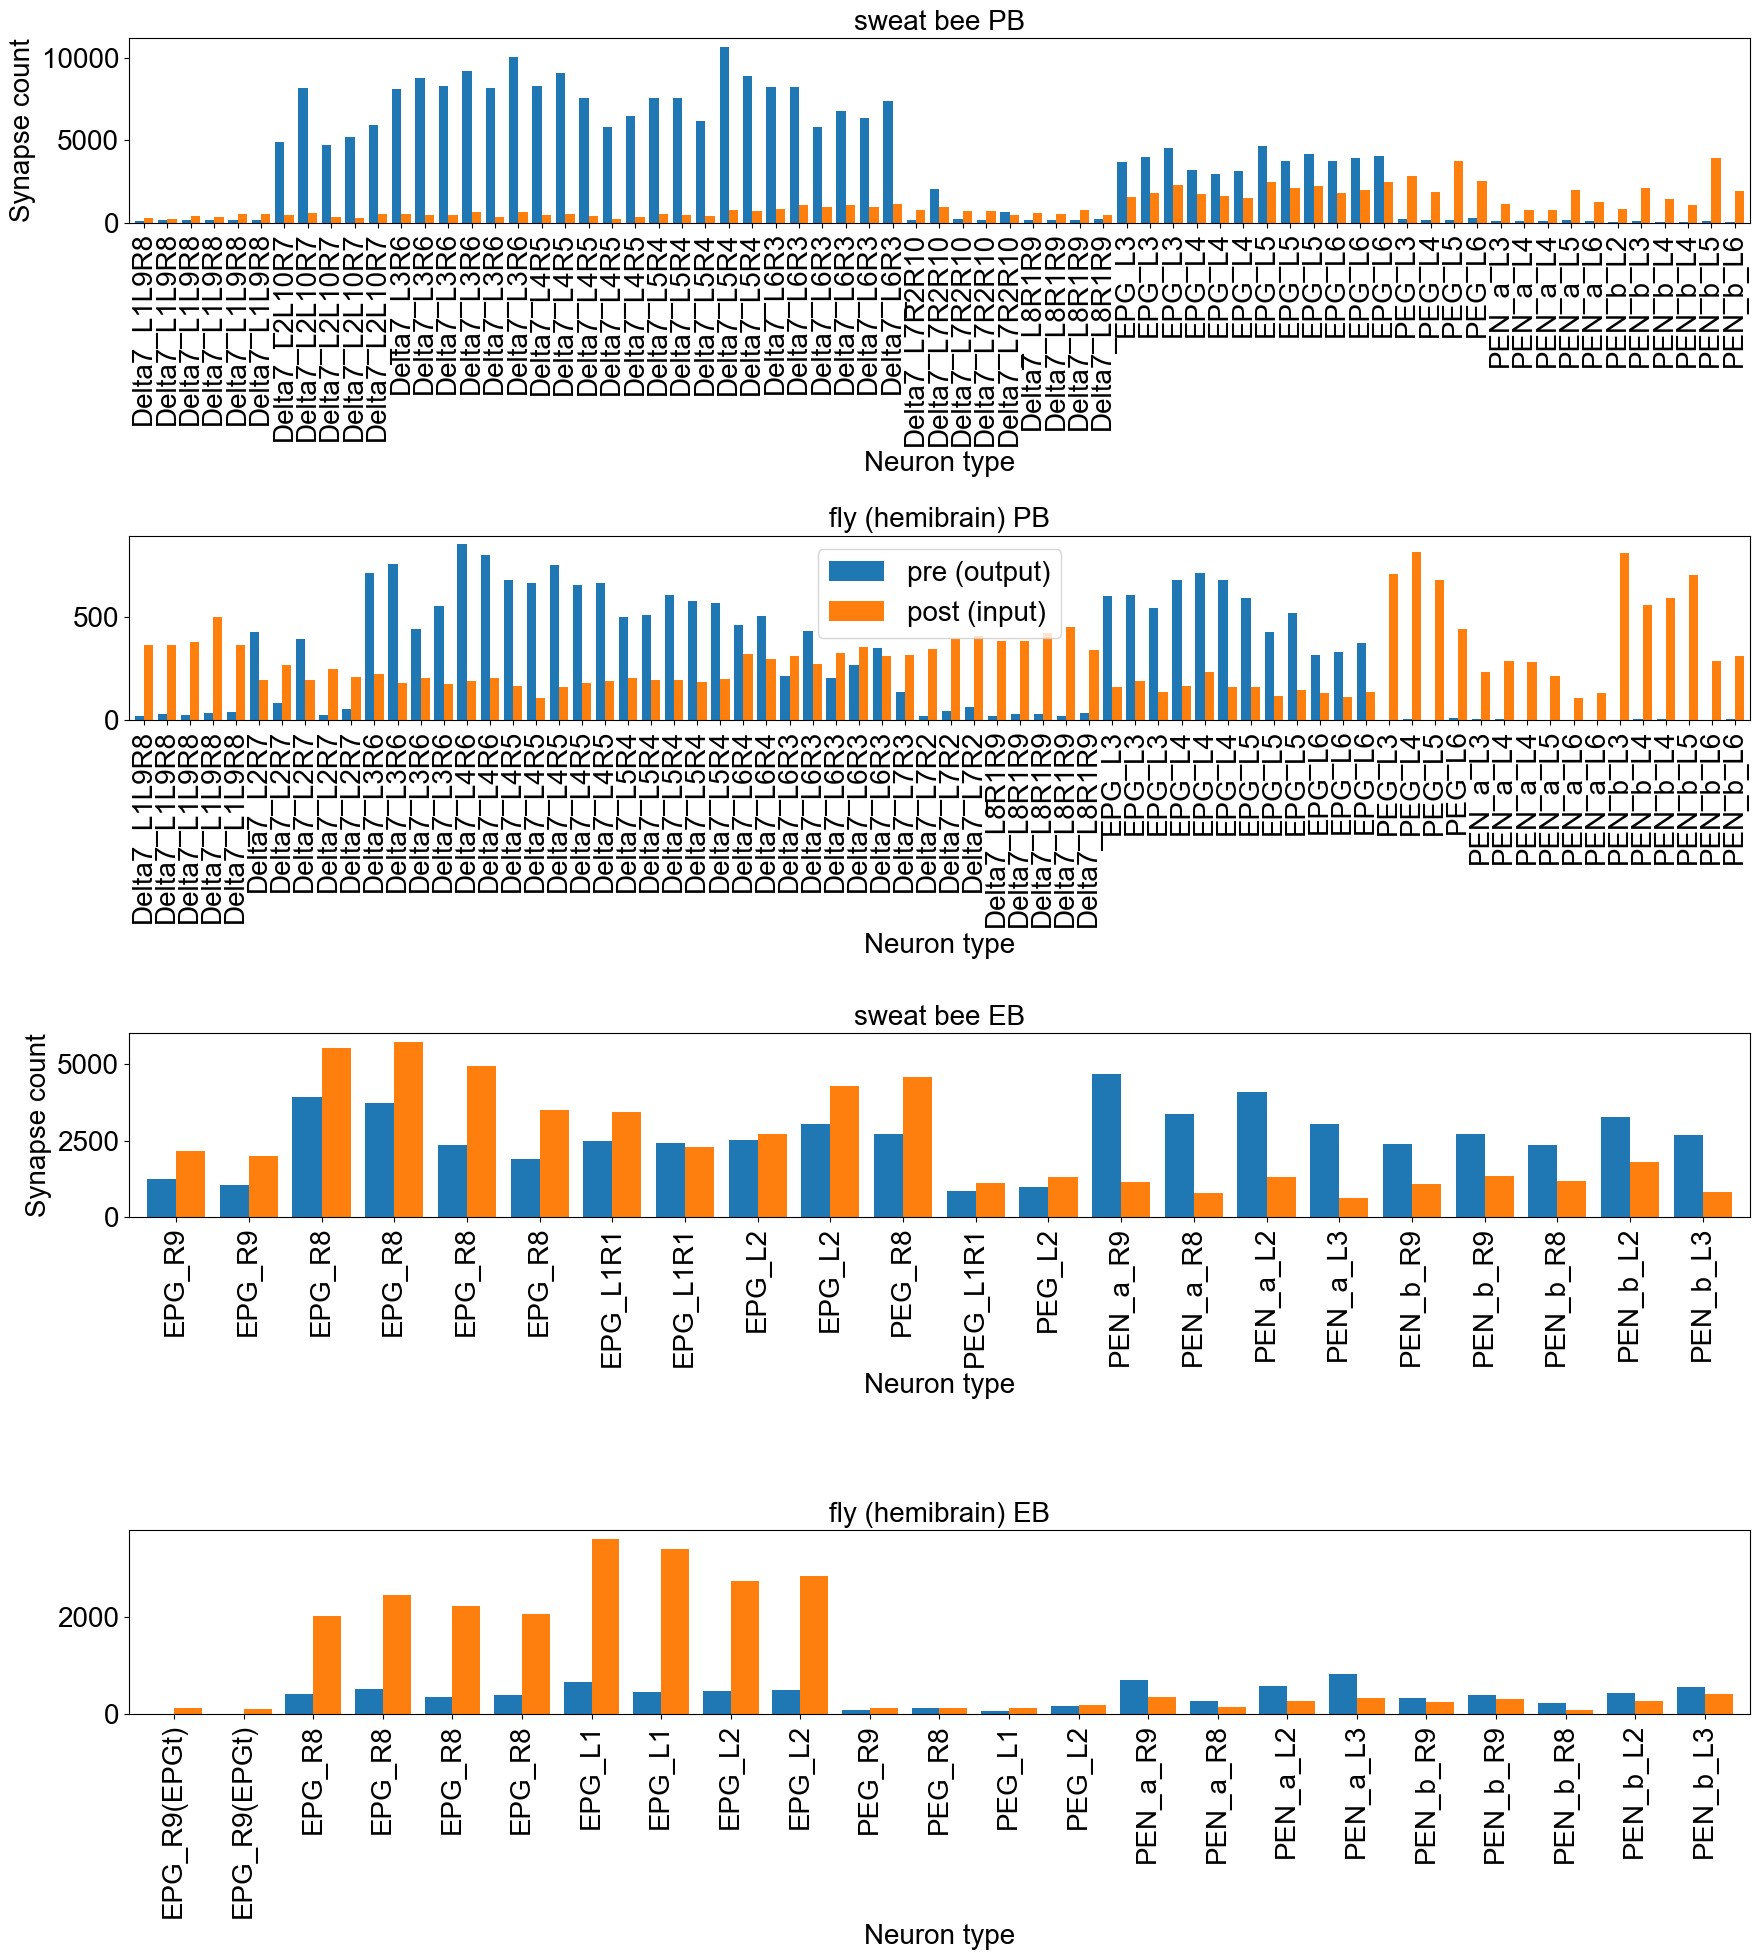

In [17]:
# --- BEE side --

bee_pre = (
    bee_syn_df
    .groupby(['pre_name', 'type_pre_col', 'roi'], as_index=False)
    .size()
    .rename(columns={'size': 'count'})
)

bee_post = (
    bee_syn_df
    .groupby(['post_name', 'type_post_col', 'roi'], as_index=False)
    .size()
    .rename(columns={'size': 'count'})
)

filters = {
    'PB': r'EPG_R1|EPG_L1|PEG_R1|PEG_L1|EPG_L2|PEG_L2|PEN_a_L2|PEN2_L2|EPG_L7|PEG_L7|PEN_L7|PFN|PFL|PFEx',
    'EB': r'EPG_L3|L4|L5|L6|L7|L8|L9|R6|R5|R4|R3|R2|PFN|PFL|PFE|delta|PEN_R7'
}

color_map = {
    'pre (output)': 'tab:blue',
    'post (input)': 'tab:orange'
}

rois = ['PB', 'EB']

bee_plot_data = {}

for roi in rois:
    # ---------- PRE ----------
    pre_df = bee_pre[bee_pre['roi'] == roi].copy()
    pre_df = pre_df[
        ~pre_df['type_pre_col'].str.contains(filters[roi], regex=True, na=False)
    ]

    # neuron = individual neuron (unique index)
    # label  = neuron TYPE (shown on x-axis)
    pre_df['neuron'] = pre_df['pre_name']
    pre_df['label'] = pre_df['type_pre_col']
    pre_df['type'] = 'pre (output)'

    # ---------- POST ----------
    post_df = bee_post[bee_post['roi'] == roi].copy()
    post_df = post_df[
        ~post_df['type_post_col'].str.contains(filters[roi], regex=True, na=False)
    ]

    post_df['neuron'] = post_df['post_name']
    post_df['label'] = post_df['type_post_col']
    post_df['type'] = 'post (input)'

    # ---------- COMBINE ----------
    combined = pd.concat(
        [pre_df[['neuron', 'label', 'count', 'type']],
         post_df[['neuron', 'label', 'count', 'type']]],
        ignore_index=True
    )

    # sort by TYPE, but keep neurons distinct
    combined['sort_key'] = combined['label'].apply(create_sort_key)

    sorted_neurons = (
        combined[['neuron', 'sort_key']]
        .drop_duplicates()
        .sort_values('sort_key')['neuron']
    )

    plot_df = (
        combined.pivot(index='neuron', columns='type', values='count')
        .fillna(0)
        .astype(int)
    )

    plot_df = plot_df.loc[sorted_neurons]

    # store labels separately for plotting
    plot_df['label'] = combined.drop_duplicates('neuron').set_index('neuron')['label']

    bee_plot_data[roi] = plot_df

# remove ER cells <- temp commented out

if 'EB' in bee_plot_data:
    df = bee_plot_data['EB'].copy()

    mask = ~df['label'].str.contains(r'ER', na=False)
    bee_plot_data['EB'] = df.loc[mask]


# --- FLY side: group by pre_name/post_name, label by type_pre_col/type_post_col ---

# Keep only connections where BOTH sides are within the same ROI
fly_PB_filt = fly_syn_df[
    fly_syn_df['roi_pre'].str.contains(r'PB', na=False) &
    fly_syn_df['roi_post'].str.contains(r'PB', na=False)
].copy()

fly_EB_filt = fly_syn_df[
    fly_syn_df['roi_pre'].str.contains(r'EB', na=False) &
    fly_syn_df['roi_post'].str.contains(r'EB', na=False)
].copy()

roi_dfs = {
    'PB': fly_PB_filt,
    'EB': fly_EB_filt,
}

# Build "pre" and "post" count tables 
fly_plot_data = {}

for roi, df in roi_dfs.items():
    df = df.copy()
    df['roi'] = roi  # unify label

    required = {'pre_name', 'post_name', 'type_pre_col', 'type_post_col'}
    missing = required.difference(df.columns)
    if missing:
        raise KeyError(f"Fly df for {roi} missing columns: {missing}. Available: {list(df.columns)}")

    fly_pre = (
        df.groupby(['pre_name', 'type_pre_col', 'roi'], as_index=False)
          .size()
          .rename(columns={'size': 'count'})
    )

    fly_post = (
        df.groupby(['post_name', 'type_post_col', 'roi'], as_index=False)
          .size()
          .rename(columns={'size': 'count'})
    )


    pre_df = fly_pre[fly_pre['roi'] == roi].copy()
    pre_df['neuron'] = pre_df['pre_name']          # individual identity
    pre_df['label']  = pre_df['type_pre_col']      # type label
    pre_df['type']   = 'pre (output)'

    post_df = fly_post[fly_post['roi'] == roi].copy()
    post_df['neuron'] = post_df['post_name']
    post_df['label']  = post_df['type_post_col']
    post_df['type']   = 'post (input)'

    combined = pd.concat(
        [pre_df[['neuron', 'label', 'count', 'type']],
         post_df[['neuron', 'label', 'count', 'type']]],
        ignore_index=True
    )

    # sort by TYPE label, but keep neurons distinct
    combined['sort_key'] = combined['label'].apply(create_sort_key)

    sorted_neurons = (
        combined[['neuron', 'sort_key']]
        .drop_duplicates()
        .sort_values('sort_key')['neuron']
    )

    plot_df = (
        combined.pivot(index='neuron', columns='type', values='count')
        .fillna(0)
        .astype(int)
    )

    # Ensure both columns exist (in case one side missing for some neurons)
    for col in ['pre (output)', 'post (input)']:
        if col not in plot_df.columns:
            plot_df[col] = 0

    plot_df = plot_df.loc[sorted_neurons]

    # store labels for xticks
    plot_df['label'] = combined.drop_duplicates('neuron').set_index('neuron')['label']

    fly_plot_data[roi] = plot_df

if 'EB' in fly_plot_data:
    df = fly_plot_data['EB'].copy()

    mask = ~df['label'].str.contains(r'ER', na=False)
    fly_plot_data['EB'] = df.loc[mask]

# --- PLOTTING ---

nrows = len(rois) * 2

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=1,
    figsize=(18, 5 * nrows), # 16 should be 4
    sharey=False
)

axes = np.atleast_1d(axes)

bar_cols = ['pre (output)', 'post (input)']

row = 0
for roi in rois:
    # ---------- BEE ----------
    ax_bee = axes[row]
    bee_df_plot = bee_plot_data[roi]

    bee_df_plot[bar_cols].plot(
        kind='bar',
        ax=ax_bee,
        color=[color_map[c] for c in bar_cols],
        width=0.8,
        legend=False
    )

    ax_bee.set_xticklabels(
        bee_df_plot['label'].tolist(),
        rotation=90
    )

    ax_bee.set_title(f"sweat bee {roi}")
    ax_bee.set_ylabel("Synapse count")
    ax_bee.set_xlabel("Neuron type")

    # ---------- FLY (share y with bee) ----------
    ax_fly = axes[row + 1]
    fly_df_plot = fly_plot_data[roi]

    fly_df_plot[bar_cols].plot(
        kind='bar',
        ax=ax_fly,
        color=[color_map[c] for c in bar_cols],
        width=0.8
    )

    ax_fly.set_xticklabels(
        fly_df_plot['label'].tolist(),
        rotation=90
    )

    ax_fly.set_title(f"fly (hemibrain) {roi}")
    ax_fly.set_xlabel("Neuron type")

    # SHARE Y AXIS WITH BEE (not used)
    # ax_fly.sharey(ax_bee)

    # Legend once
    if row == 0:
        ax_fly.legend()
    else:
        ax_fly.get_legend().remove()

    row += 2

plt.tight_layout()
file_path = os.path.join(
    save_dir,
    f"bee_fly_synapse_bargraphs_allROIs_{today}.pdf"
)

plt.savefig(file_path, bbox_inches='tight', pad_inches=0, format='pdf')
print(f"Plot saved: {file_path}")
plt.show()

### FAFB synapse count per neuron

In [217]:
fafb_syn_df = pd.read_csv('../syntables/fafb_core_cell_syntable.csv')
fafb_syn_df = fafb_syn_df.rename(columns= {'type_col':'type_col'})
fafb_syn_df

,Unnamed: 0,id,neuropil,pre,post,name,type_col
0,0,720575940623852873,CRE_R,41.0,13.0,EPG_R8_720575940623852873,EPG_R8
1,1,720575940623852873,EB,916.0,1067.0,EPG_R8_720575940623852873,EPG_R8
2,2,720575940623852873,FB,0.0,7.0,EPG_R8_720575940623852873,EPG_R8
3,3,720575940623852873,GA_R,250.0,54.0,EPG_R8_720575940623852873,EPG_R8
4,4,720575940623852873,IB_L,0.0,2.0,EPG_R8_720575940623852873,EPG_R8
...,...,...,...,...,...,...,...
157,157,720575940612763158,EB,1204.0,494.0,PEN2_L3_720575940612763158,PEN2_L3
158,158,720575940612763158,FB,11.0,0.0,PEN2_L3_720575940612763158,PEN2_L3
159,159,720575940612763158,LAL_L,0.0,1.0,PEN2_L3_720575940612763158,PEN2_L3
160,160,720575940612763158,NO,425.0,426.0,PEN2_L3_720575940612763158,PEN2_L3


In [221]:
fafb_PB = fafb_syn_df[fafb_syn_df['neuropil'].str.contains(r'^PB$')]
fafb_EB = fafb_syn_df[fafb_syn_df['neuropil'].str.contains(r'^EB$')]
fafb_PB

,Unnamed: 0,id,neuropil,pre,post,name,type_col
9,9,720575940623852873,PB,806.0,83.0,EPG_R8_720575940623852873,EPG_R8
16,16,720575940635427982,PB,710.0,89.0,EPG_R8_720575940635427982,EPG_R8
25,25,720575940624096234,PB,232.0,34.0,EPG_R8_720575940624096234,EPG_R8
34,34,720575940633719487,PB,513.0,51.0,EPG_R8_720575940633719487,EPG_R8
41,41,720575940628843458,PB,615.0,80.0,EPG_L1_720575940628843458,EPG_L1
48,48,720575940631125036,PB,803.0,115.0,EPG_L1_720575940631125036,EPG_L1
57,57,720575940608722371,PB,941.0,108.0,EPG_L2_720575940608722371,EPG_L2
66,66,720575940613829900,PB,877.0,123.0,EPG_L2_720575940613829900,EPG_L2
73,73,720575940602917088,PB,664.0,181.0,EPGt_R9_720575940602917088,EPGt_R9
81,81,720575940619905404,PB,614.0,182.0,EPGt_R9_720575940619905404,EPGt_R9


Plot saved: D:\Github\bee-ant-head-direction\analysis\plots\FAFB synapse counts per neuron in PB.pdf


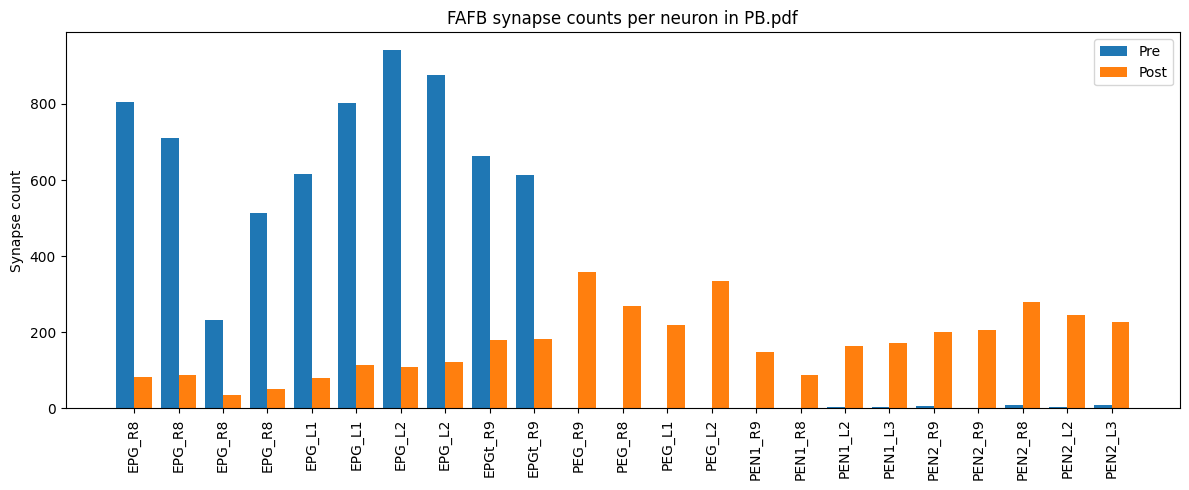

Plot saved: D:\Github\bee-ant-head-direction\analysis\plots\FAFB synapse counts per neuron in EB.pdf


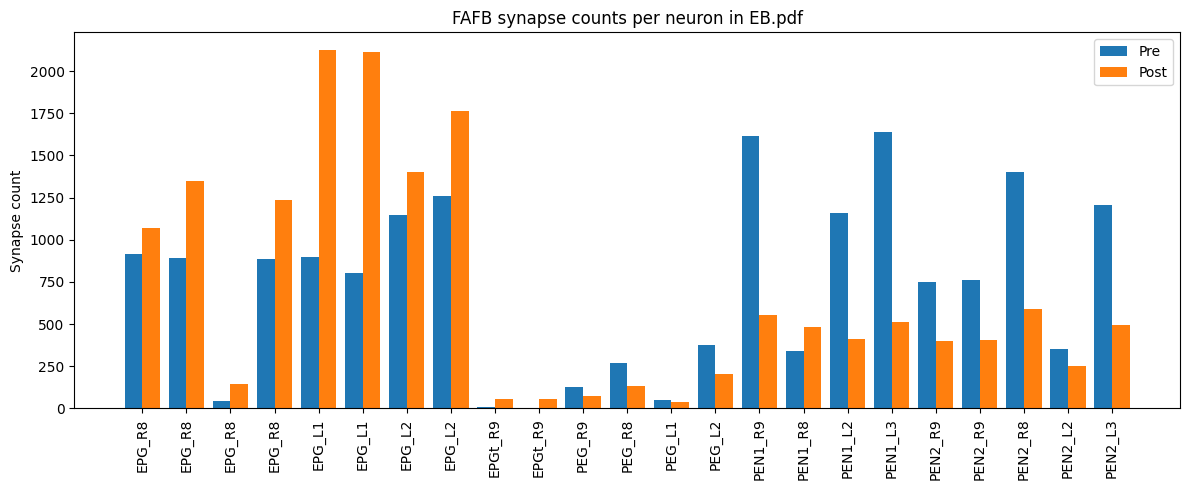

In [227]:
# Build custom sort keys per ROI
roi_dfs = {
    'PB': fafb_PB,
    'EB': fafb_EB
}

# Step 1: Precompute sorted order per ROI
sorted_type_cols = {}
for roi, df in roi_dfs.items():
    df = df.copy()
    df['sort_key'] = df['type_col'].apply(create_sort_key)
    sorted_type_cols[roi] = (
        df[['type_col', 'sort_key']]
        .drop_duplicates()
        .sort_values('sort_key')
        ['type_col']
    )

# Step 2: Plot using sort keys per ROI
for roi, df in roi_dfs.items():
    df = df.copy()

    if not {'type_col', 'pre', 'post'}.issubset(df.columns):
        print(f"Missing columns in {roi}")
        continue

    # Apply roi-specific sort order
    df['type_col'] = pd.Categorical(df['type_col'], categories=sorted_type_cols[roi], ordered=True)
    df = df.sort_values('type_col')

    # Plot
    x = range(len(df))
    width = 0.4

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.bar([i - width/2 for i in x], df['pre'], width=width, label='Pre')
    ax.bar([i + width/2 for i in x], df['post'], width=width, label='Post')

    ax.set_xticks(x)
    ax.set_xticklabels(df['type_col'], rotation=90)
    ax.set_ylabel("Synapse count")
    title=f"FAFB synapse counts per neuron in {roi}.pdf"
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()

    # Construct the filename and save the plot
    file_path = os.path.join(save_dir, title)
    plt.savefig(file_path, bbox_inches = 'tight', pad_inches=0, format='pdf')
    print(f"Plot saved: {file_path}")
    
    plt.show()


### comparison across bee, hemibrain, fafb

In [192]:
# Group and rename pre counts
bee_gp_pre_eb = bee_pre_EB.groupby('type_pre_col').sum().astype(int).rename(columns={
    'count': 'bee_pre'
}).reset_index().rename(columns={'type_pre_col': 'type_col'})

# Group and rename post counts
bee_gp_post_eb = bee_post_EB.groupby('type_post_col').sum().astype(int).rename(columns={
    'count': 'bee_post'
}).reset_index().rename(columns={'type_post_col': 'type_col'})


bee_gp = bee_gp_pre_eb.merge(bee_gp_post_eb, on=['type_col'], how='outer')
bee_gp = bee_gp.replace({'PEG_R1': 'PEG_L1'}, regex=True)
bee_gp

C:\Users\Marcel\AppData\Local\Temp\ipykernel_21048\361522524.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  bee_gp_pre_eb = bee_pre_EB.groupby('type_pre_col').sum().astype(int).rename(columns={
C:\Users\Marcel\AppData\Local\Temp\ipykernel_21048\361522524.py:7: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  bee_gp_post_eb = bee_post_EB.groupby('type_post_col').sum().astype(int).rename(columns={


,type_col,bee_pre,bee_post
0,EPG_L1,420,731
1,EPG_L2,507,959
2,EPG_R8,1134,2716
3,EPGt_R9,82,261
4,PEG_L2,115,199
5,PEG_L1,78,113
6,PEG_R8,412,598
7,PEN1_L2,661,186
8,PEN1_L3,526,90
9,PEN1_R8,279,65


In [193]:
fafb_gp = fafb_EB.rename(columns= {'pre': 'fafb_pre', 'post': 'fafb_post') 
fafb_gp = fafb_gp.groupby('type_col')[['fafb_pre', 'fafb_post']].sum().astype(int).reset_index()
fafb_gp


,type_col,fafb_pre,fafb_post
0,EPG_L1,1703,4235
1,EPG_L2,2410,3165
2,EPG_R8,2737,3794
3,EPGt_R9,13,111
4,PEG_L1,48,38
5,PEG_L2,374,204
6,PEG_R8,267,132
7,PEG_R9,128,76
8,PEN1_L2,1158,411
9,PEN1_L3,1638,511


In [194]:
hemibrain_gp = fly_EB_filt.rename(columns= {'pre': 'hemibrain_pre', 'post': 'hemibrain_post'}) 
hemibrain_gp = hemibrain_gp.groupby('type_col')[['hemibrain_pre', 'hemibrain_post']].sum().astype(int).reset_index()
hemibrain_gp

,type_col,hemibrain_pre,hemibrain_post
0,EPG_L1,591,9045
1,EPG_L2,517,7457
2,EPG_R8,840,11305
3,EPGt_R9,14,345
4,PEG_L1,100,183
5,PEG_L2,134,310
6,PEG_R8,92,169
7,PEG_R9,96,184
8,PEN1_L2,433,817
9,PEN1_L3,481,831


In [195]:
all_gp = bee_gp.merge(fafb_gp, on=['type_col'], how='outer')
all_gp = all_gp.merge(hemibrain_gp, on=['type_col'], how='outer')
all_gp = all_gp[~all_gp['type_col'].str.contains(r'PEG_R9|EPGt_R9')]
all_gp

,type_col,bee_pre,bee_post,fafb_pre,fafb_post,hemibrain_pre,hemibrain_post
0,EPG_L1,420.0,731.0,1703,4235,591,9045
1,EPG_L2,507.0,959.0,2410,3165,517,7457
2,EPG_R8,1134.0,2716.0,2737,3794,840,11305
4,PEG_L2,115.0,199.0,374,204,134,310
5,PEG_L1,78.0,113.0,48,38,100,183
6,PEG_R8,412.0,598.0,267,132,92,169
7,PEN1_L2,661.0,186.0,1158,411,433,817
8,PEN1_L3,526.0,90.0,1638,511,481,831
9,PEN1_R8,279.0,65.0,341,480,461,885
10,PEN1_R9,825.0,159.0,1618,555,385,805


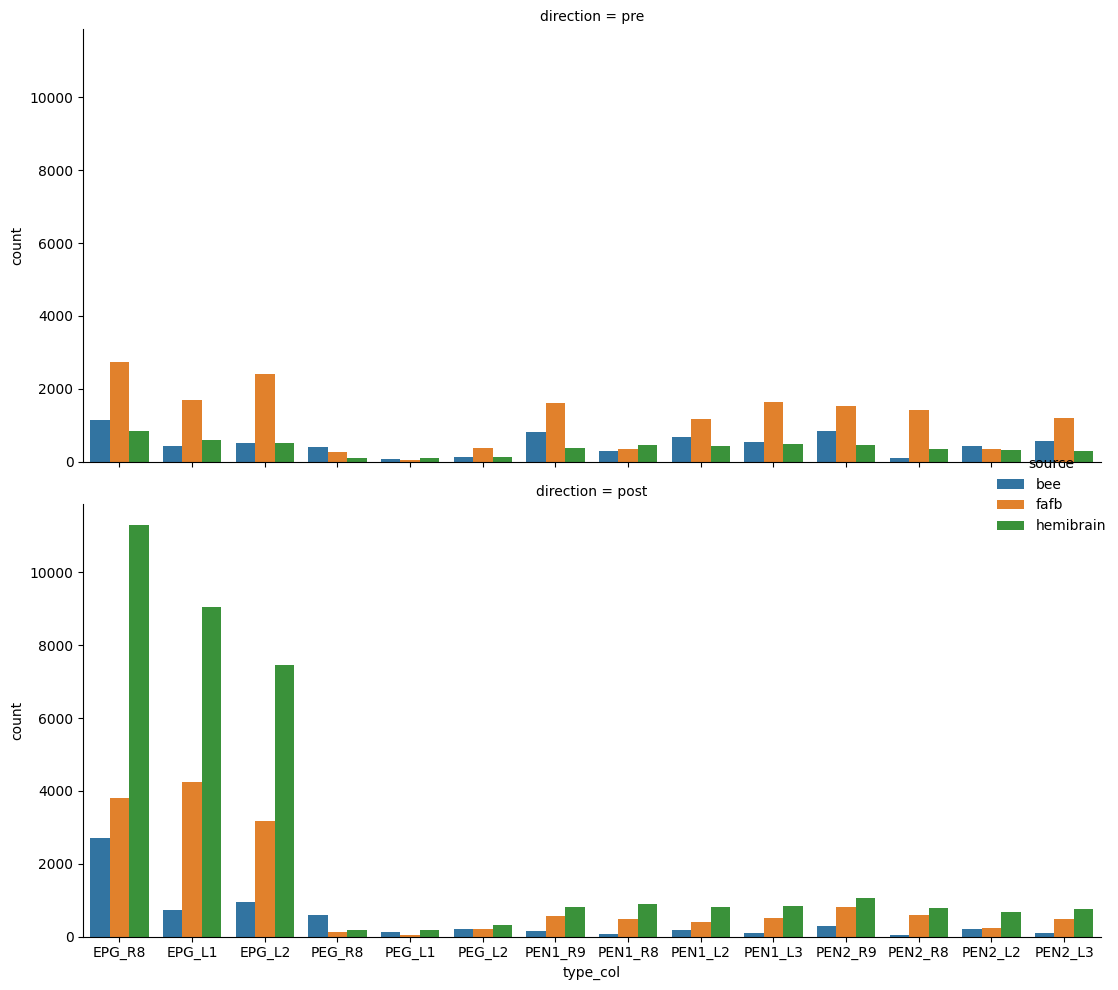

In [203]:
# 1. Melt the original DataFrame (assumed to be `all_gp`)
melted = all_gp.melt(
    id_vars='type_col',
    value_vars=['bee_pre', 'bee_post', 'fafb_pre', 'fafb_post', 'hemibrain_pre', 'hemibrain_post'],
    var_name='source_type',
    value_name='count'
)

# 2. Split source_type into 'source' and 'direction'
melted[['source', 'direction']] = melted['source_type'].str.split('_', expand=True)

# 3. Compute and apply custom sort key
melted['sort_key'] = melted['type_col'].apply(create_sort_key)
sorted_type_col = (
    melted[['type_col', 'sort_key']]
    .drop_duplicates()
    .sort_values('sort_key')
    ['type_col']
)



Plot saved: D:\Github\bee-ant-head-direction\analysis\plots\pre count species comparison.pdf


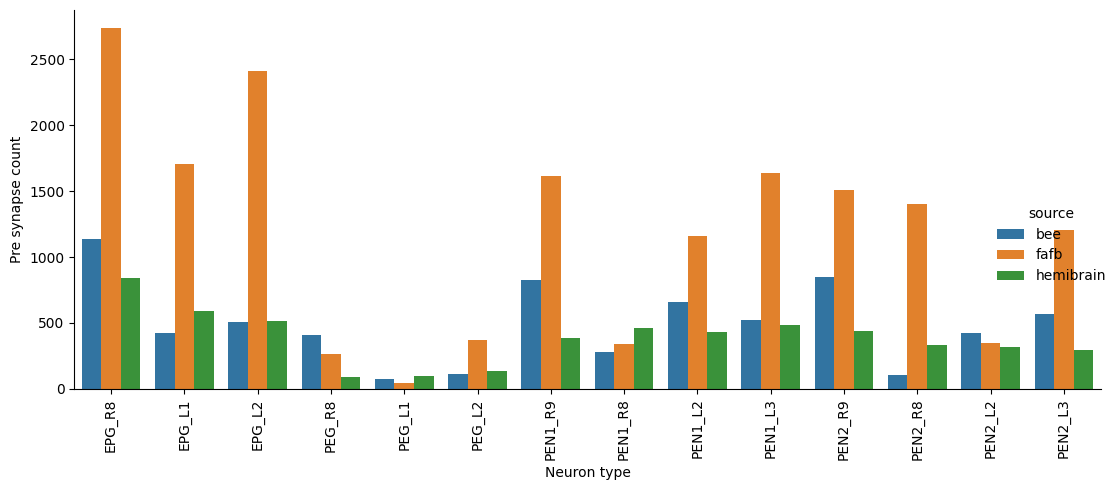

Plot saved: D:\Github\bee-ant-head-direction\analysis\plots\post count species comparison.pdf


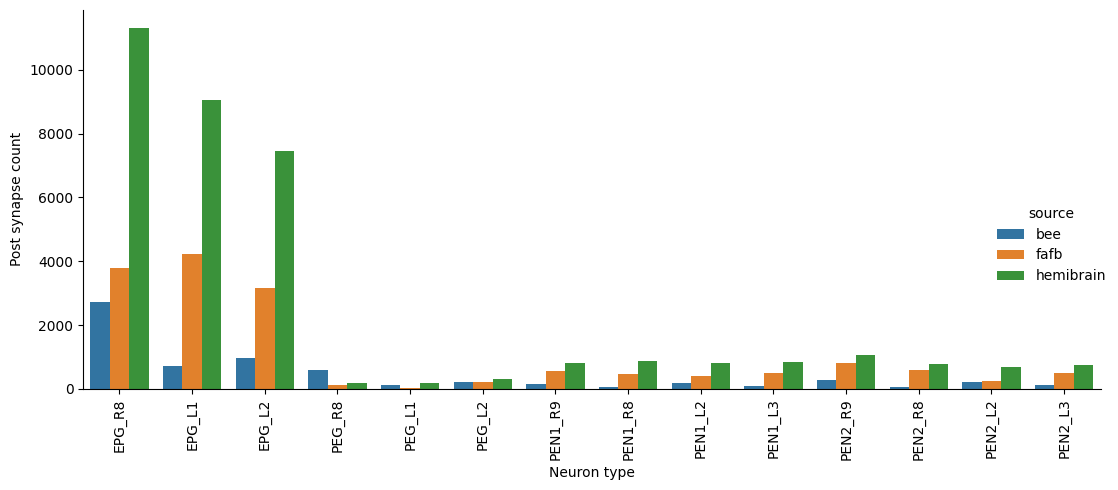

In [223]:
# Separate data for pre and post
melted_pre = melted[melted['direction'] == 'pre']
melted_post = melted[melted['direction'] == 'post']

# Sort order (reuse previous sort)
sorted_type_col = (
    melted[['type_col', 'sort_key']]
    .drop_duplicates()
    .sort_values('sort_key')['type_col']
)

# Plot 'pre'
g_pre = sns.catplot(
    data=melted_pre,
    x='type_col',
    y='count',
    hue='source',
    kind='bar',
    height=5,
    aspect=2,
    order=sorted_type_col
)
g_pre.set_axis_labels("Neuron type", "Pre synapse count")
g_pre.set_titles("Pre Synapses")
g_pre.set_xticklabels(rotation=90)
plt.tight_layout()
title = 'pre count species comparison.pdf'
file_path = os.path.join(save_dir, title)
plt.savefig(file_path, bbox_inches = 'tight', pad_inches=0, format='pdf')
print(f"Plot saved: {file_path}")

plt.show()
###########################
# Plot 'post'
g_post = sns.catplot(
    data=melted_post,
    x='type_col',
    y='count',
    hue='source',
    kind='bar',
    height=5,
    aspect=2,
    order=sorted_type_col
)
g_post.set_axis_labels("Neuron type", "Post synapse count")
g_post.set_titles("Post Synapses")
g_post.set_xticklabels(rotation=90)
plt.tight_layout()

# Construct the filename and save the plot
title = 'post count species comparison.pdf'
file_path = os.path.join(save_dir, title)
plt.savefig(file_path, bbox_inches = 'tight', pad_inches=0, format='pdf')
print(f"Plot saved: {file_path}")

plt.show()